<a href="https://colab.research.google.com/github/wangwangwang77/Machine-learning-in-UM/blob/main/Copy_of_Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip uninstall -y tensorflow keras


Found existing installation: tensorflow 2.13.0
Uninstalling tensorflow-2.13.0:
  Successfully uninstalled tensorflow-2.13.0
Found existing installation: keras 2.13.1
Uninstalling keras-2.13.1:
  Successfully uninstalled keras-2.13.1


In [ ]:
!pip install tensorflow==2.13.0 keras==2.13.1

  Using cached tensorflow-2.13.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (3.4 kB)
  Using cached keras-2.13.1-py3-none-any.whl.metadata (2.4 kB)
Using cached tensorflow-2.13.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (524.2 MB)
Using cached keras-2.13.1-py3-none-any.whl (1.7 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.18.1 requires tensorflow<2.19,>=2.18.0, but you have tensorflow 2.13.0 which is incompatible.
tf-keras 2.18.0 requires tensorflow<2.19,>=2.18, but you have tensorflow 2.13.0 which is incompatible.


In [ ]:
import sys
import numpy as np
import pandas as pd
import os
from functools import reduce
from tensorflow.keras.layers import Normalization
import tensorflow as tf
from google.colab import drive

# Mount your Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install openpyxl
!pip install tabulate
from tabulate import tabulate

In [ ]:
from google.colab import files

# Step 1: Upload your file
print("Please upload your Python file:")
uploaded = files.upload()

Please upload your Python file:


KeyboardInterrupt: 

In [ ]:
for filename in uploaded.keys():
    print(f"Processing file: {filename}")

    # Read the file content
    with open(filename, 'r', encoding='utf-8') as file:
        content = file.read()

    # Replace unusual line terminators with standard newlines
    content = content.replace('\u2028', '\n').replace('\u2029', '\n')

    # Save the cleaned file
    cleaned_filename = f"cleaned_{filename}"
    with open(cleaned_filename, 'w', encoding='utf-8') as cleaned_file:
        cleaned_file.write(content)

    print(f"Cleaned file saved as: {cleaned_filename}")

In [ ]:
print("Preparing the cleaned file for download...")
files.download(cleaned_filename)  # Triggers download

Class Economy


In [ ]:
from scipy.stats import pearsonr
import statsmodels.api as sm
from statsmodels.tsa.api import VAR

class economy:

    """
    Parameters:

    """
    def __init__(self, numAssets, numStates, numPeriods, numSim):

        # pass information for the simulation
        self.numPeriods = numPeriods
        self.numAssets = numAssets
        self.numStates = numStates
        self.numSim = numSim

    def simulation(self, parModel):

        simData = eval("self."+parModel["model"])(parModel)

        return simData

    def bootstrap_data_Ic_9(self, parModel):

        numBatches = parModel["numBatches"]
        expected_block_length = 20
        maturity = (self.numPeriods + 1) * self.numSim * numBatches  # New fixed number of samples for each bootstrap draw
        p = 1 / expected_block_length
        rng = np.random.default_rng(7)

        drive.mount("/content/drive", force_remount=True)
        file_path = '/content/drive/My Drive/project data/industry_porfolio(new).xlsx'

        df_IP = pd.read_excel(file_path, engine="openpyxl")
        df_IP = df_IP.iloc[1:]
        df_IP.columns = ['Year', 'Construction_Ip', 'Finance_Ip', 'Manuf_Ip','Mining_Ip', 'retail_Ip', 'Service_Ip','Comm. Util._Ip', 'wholesale_Ip']
        df_IP = df_IP.map(lambda x: str(x).replace('\xa0', '') if isinstance(x, str) else x)
        #df_IP = df_IP.applymap(lambda x: str(x).replace('\xa0', '') if isinstance(x, str) else x)
        df_IP= df_IP.apply(pd.to_numeric, errors='coerce')
        df_IP.iloc[:, 1:] = df_IP.iloc[:, 1:]/ 100 + 1
        df_IP.iloc[:, 1:] = df_IP.iloc[:, 1:].round(6)

        file_path = '/content/drive/My Drive/project data/F-F_Research_Data_Factors.xlsx'
        df1 = pd.read_excel(file_path, engine="openpyxl")# Try different delimiters if neede
        df1 = df1.iloc[1:]
        df1.columns = ['Year', 'Mkt', 'RF']
        df1['Mkt']=  df1['Mkt']/100 + 1
        df1['RF'] = df1['RF']/100 + 1


        file_path_IC = '/content/drive/My Drive/project data/split_yearlyPerCapitaWages(new).xlsx'

        df_IC = pd.read_excel(file_path_IC, sheet_name="sheet1", engine="openpyxl")
        df_IC.columns = ['Year', 'Construction', 'Finance', 'Manufacturing', 'Mining', 'retail',
                        'Services', 'Comm. Util.', 'Wholesale', 'Government']

        select_columns = ['Construction', 'Finance', 'Manufacturing', 'Mining', 'retail', 'Services',
                          'Comm. Util.', 'Wholesale','Government']

        df_IC[select_columns] = df_IC[select_columns].apply(
            lambda x: x[1:].values / x[:-1].values)

        df_IC_lagged = df_IC.copy()
        df_IC_lagged['Year'] = df_IC_lagged['Year'] + 1

        file_path_dp = '/content/drive/My Drive/project data/predicor_industry.xlsx'

        df_dp = pd.read_excel(file_path_dp, sheet_name="Sheet1", usecols="A:E", engine="openpyxl")
        df_dp.columns = ["Year", "dp_market", "dp_constr","Fin_dp","dp_manuf"]
        # Reset the index, if necessary
        df_dp = df_dp.reset_index(drop=True)
        #df_dp['Year'] = pd.to_numeric(df_dp['Year'], errors='coerce')

        #df_IC.iloc[:, 1:] = df_IC.iloc[:, 1:] + 1

        file_path_cpi = '/content/drive/My Drive/project data/CPI.xlsx'
        df_If = pd.read_excel(file_path_cpi, sheet_name="sheet2", engine="openpyxl")
        df_If.columns = ['Year', 'inflation']

        df_dp_lagged = df_dp.copy()
        df_dp_lagged['Year'] = df_dp_lagged['Year'] + 1

        dfs = [df_IP, df1, df_dp, df_IC_lagged, df_If]

        merged_df = reduce(lambda left, right: pd.merge(left, right, on='Year', how='inner'), dfs)

        # Extract predictors (current period)
        dp_mkt = merged_df['dp_market'].to_numpy()[1:]  # t=0 to n-2
        dp_mkt_lag = merged_df['dp_market'].to_numpy()[:-1]  # t=0 to n-2
        dp_mkt_lag = np.log(dp_mkt_lag)
        dp_con = merged_df['dp_constr'].to_numpy()[1:]  # t=0 to n-2
        dp_con_lag = merged_df['dp_constr'].to_numpy()[:-1]  # t=0 to n-2
        dp_con_lag = np.log(dp_con_lag)

        # Extract outcomes (next period)
        r_mkt = merged_df['Mkt'].to_numpy()[1:] # t=1 to n-1
        rf = merged_df['RF'].to_numpy()[1:]
        ex_r_mkt = np.log(r_mkt)- np.log(rf)

        r_mkt_lag = merged_df['Mkt'].to_numpy()[:-1]
        rf_lag = merged_df['RF'].to_numpy()[:-1]
        ex_r_mkt_lag = np.log(r_mkt_lag) - np.log(rf_lag)
        constr_p = merged_df['Construction_Ip'].to_numpy()[1:]  # t=1 to n-1
        ex_constr_p = np.log(constr_p) - np.log(rf)
        constr_p_lag = merged_df['Construction_Ip'].to_numpy()[:-1]
        ex_constr_p_lag = np.log(constr_p_lag) - np.log(rf_lag)

        dp_mkt = dp_mkt.reshape(-1, 1)
        dp_con = dp_con.reshape(-1, 1)

        # Stack independent variables
        independent_vars1 = np.column_stack((ex_constr_p_lag,dp_con_lag))  # (58, 3)
        independent_vars2 = np.column_stack((ex_r_mkt_lag,dp_mkt_lag))  # (58, 3)

        independent_vars1 = sm.add_constant(independent_vars1)
        independent_vars2 = sm.add_constant(independent_vars2)

        model_1 = sm.OLS(ex_constr_p, independent_vars1).fit()
        print(model_1.summary())
        model_2 = sm.OLS(ex_r_mkt, independent_vars2).fit()
        print(model_2.summary())

        mean_market_return = ex_r_mkt.mean()
        mean_market_return_lag = ex_r_mkt_lag.mean()
        mean_dp_market_lag = dp_mkt_lag.mean()

        mean_constr_p = ex_constr_p.mean()
        mean_constr_p_lag = ex_constr_p_lag.mean()
        mean_dp_con_lag = dp_con_lag.mean()

        # Extract estimated coefficients
        beta_1 = model_1.params[1]
        beta_2 = model_1.params[2]

        beta_3 = model_2.params[1]
        beta_4 = model_2.params[2]

        # Compute adjusted intercept (c) using the mean constraint
        c_adjusted = (1 - beta_1) * mean_constr_p_lag - beta_2 * mean_dp_con_lag
        c_adjusted_2 = (1 - beta_3) * mean_market_return_lag - beta_4 * mean_dp_market_lag

        # Replace intercept with the adjusted value
        params_adjusted = model_2.params.copy()
        params_adjusted[0] = c_adjusted_2

        Y_pred_constrained = c_adjusted_2 + beta_3 * ex_r_mkt_lag + beta_4 * dp_mkt_lag

        # Compute constrained residuals
        residuals_constrained =  ex_r_mkt - Y_pred_constrained

        n = len(residuals_constrained)  # Number of observations
        k = 3 # Number of estimated parameters (including intercept)

        # Compute residual variance
        residual_variance_constrained = (residuals_constrained.T @ residuals_constrained) / (n - k)

        ones_array = np.ones_like(ex_r_mkt_lag) * c_adjusted_2

        X = np.column_stack((ones_array, ex_r_mkt_lag, dp_mkt_lag))

        # Compute variance-covariance matrix of errors
        sigma_epsilon_constrained = residual_variance_constrained * np.linalg.inv(X.T @ X)

        # Print the variance-covariance matrix
        print("\nVariance-Covariance Matrix of Errors (Constrained VAR):")
        print(sigma_epsilon_constrained)

        # Compute R-squared manually
        SS_total = np.sum((ex_r_mkt - ex_r_mkt.mean())**2)  # Total sum of squares
        SS_residual = np.sum(residuals_constrained**2)  # Residual sum of squares
        r_squared_constrained = 1 - (SS_residual / SS_total)

        print("\nAdjusted R-Squared (Constrained VAR):", r_squared_constrained)

        std_errors = np.sqrt(np.diag(sigma_epsilon_constrained))

        # Compute t-statistics
        t_stats = params_adjusted / std_errors

        # Compute p-values using normal approximation
        from scipy.stats import t
        p_values = 2 * (1 - t.cdf(np.abs(t_stats), df=n-k))  # Two-tailed test

        # Print results
        print("\nConstrained Regression Results:")
        print(pd.DataFrame({
            "Coefficient": params_adjusted,
            "Std Error": std_errors,
            "t-Statistic": t_stats,
            "p-Value": p_values
        }))

        ###################################
        #summary_stats = merged_df.agg(['mean', 'std', 'skew', 'kurtosis', 'min', 'max', 'count'])
        #print(tabulate(summary_stats, headers='keys', tablefmt='pretty'))
        ####################

        select_columns = ['Construction_Ip', 'Finance_Ip', 'Manuf_Ip','Mining_Ip', 'retail_Ip', 'Service_Ip','Comm. Util._Ip', 'wholesale_Ip','Construction', 'Finance', 'Manufacturing', 'Mining', 'retail', 'Services',
                          'Comm. Util.', 'Wholesale','Government','Mkt', 'RF']
        merged_df[select_columns] = merged_df[select_columns].apply(
            lambda x: x.values / merged_df['inflation'].values)

        ##################################
        summary_stats = merged_df.agg(['mean', 'std', 'skew', 'kurtosis', 'min', 'max', 'count'])
        #print(tabulate(summary_stats, headers='keys', tablefmt='pretty'))
        ################################
        merged_df.drop(columns=['inflation'], inplace=True)
        merged_df = merged_df.iloc[:-1]
        #print(merged_df)

        # Define two sets of columns
        set1 = ['Construction_Ip', 'Finance_Ip', 'Manuf_Ip','Mining_Ip', 'retail_Ip', 'Service_Ip','Comm. Util._Ip', 'wholesale_Ip','Mkt', 'RF']
        set2 = ['Construction', 'Finance', 'Manufacturing', 'Mining', 'retail', 'Services','Comm. Util.', 'Wholesale','Government']

        # Check for missing columns
        missing_cols1 = [col for col in set1 if col not in merged_df.columns]
        missing_cols2 = [col for col in set2 if col not in merged_df.columns]

        if missing_cols1 or missing_cols2:

          print("Missing columns in set1:", missing_cols1)
          print("Missing columns in set2:", missing_cols2)
        else:

          full_corr_matrix = merged_df[set1 + set2].corr()

          # Extract only the correlation between set1 and set2
          corr_matrix = full_corr_matrix.loc[set1, set2]

          print("\nCorrelation Matrix:\n", corr_matrix)

        # Compute p-values using Pearson correlation test
        p_values = pd.DataFrame(index=set2, columns=set1)

        for col2 in set2:
          for col1 in set1:
            _, p_value = pearsonr(merged_df[col2].values, merged_df[col1].values)
            p_values.loc[col2, col1] = p_value

        #print("\nP-value Matrix:\n", p_values)


############################################################################

        array = np.zeros((merged_df.shape))
        array = merged_df.to_numpy()
        #array[:, [-1]] = (array[:, [-1]] - np.min(array[:, [-1]])) / (np.max(array[:, [-1]]) - np.min(array[:, [-1]]))
        array = np.delete(array, [0, 1], axis=0)
        array = np.delete(array, 0, axis=1)

        simulation = self.stationary_block_bootstrap(array, p, maturity, rng)
        simData = np.empty((maturity, array.shape[1] + 1))
        simData.fill(np.nan)
        simData[:, 0:-1] = simulation
        simData[:, -1] = np.tile(np.arange(self.numPeriods + 1, 0, -1), self.numSim * numBatches)

        return  simData

    def geometric_block_length(self, p, rng):
        return rng.geometric(p)

    def stationary_block_bootstrap(self, data, p, maturity, rng):
        _, n_assets = data.shape
        bootstrapped_data = np.empty((maturity, n_assets))

        current_idx = 0
        while current_idx < maturity:
            block_length = self.geometric_block_length(p, rng)
            start_point = rng.integers(0, _)
            block_end = start_point + block_length

            if block_end <= _:
                block = data[start_point:block_end, :]
            else:
                block = data[start_point:, :]

                # block = np.concatenate((data[:, start_point:], data[:, 0: block_end - _]), axis=1)

            block_size = block.shape[0]
            if current_idx + block_size > maturity:
                block = block[:maturity - current_idx, :]
                block_size = block.shape[0]

            bootstrapped_data[current_idx:current_idx + block_size, :] = block
            current_idx += block_size

        return bootstrapped_data


Class InvestorTf

In [ ]:
import tensorflow as tf

class investorTf:
    """
    Parameters:

    1. Define the utility function 'utilFunc'
        Possibilities:
            a) 'Power'
            b) 'Exponential'
            c) 'TwoPartPower'

    2. Give the parameters in the utility function
        For 'Power': [gamma, beta]
        For 'Exponential': [a, beta]
        For 'TwoPartPower':  [gammaG, gammaL, threshold, kappa, beta]

    3. Determine wealth of investor
        Net of human capital, i.e., present value of endowments is added below


    """

    def __init__(self, utilFunc = 'Power'):


        ###########
        # define the investor

        self.utilFunc = utilFunc


    ##########################################################################
    ## Call methods
    ##########################################################################

    def utility(self, consume, parUtil):

        return eval("self."+self.utilFunc+"Util")(consume, parUtil)


    def margUtility(self, consume, parUtil):

        return eval("self."+self.utilFunc+"MargUtil")(consume, parUtil)


    def inverseMargUtility(self, util, parUtil):

        return eval("self."+self.utilFunc+"InverseMargUtil")(util, parUtil)

    ##########################################################################
    ## Two-Part Power, varying reference level
    ##########################################################################

    def TwoPartPowerVarUtil(self, consume, parUtil):

        alpha = parUtil[4]
        beta = parUtil[5]

        # Create a tensor of zeros with the same shape as consume
        thresh = tf.zeros(consume.shape, dtype=tf.float32)

        # Set the initial values for the first column
        thresh = tf.tensor_scatter_nd_update(thresh, indices=[tf.constant([tf.range(consume.shape[0]), 0])],
                                             updates=parUtil[2])

        # Define the loop for updating the remaining columns
        for iTime in range(1, consume.shape[1]):
            updates = beta * consume[:, iTime - 1] + (1 - alpha) * thresh[:, iTime - 1]
            indices = [tf.constant([tf.range(consume.shape[0]), iTime])]
            thresh = tf.tensor_scatter_nd_update(thresh, indices=indices, updates=updates)

        idx = tf.cast(consume >= thresh, dtype=tf.float32)

        firstPart = tf.math.pow(tf.math.multiply((consume - thresh), idx) + tf.keras.backend.epsilon(), parUtil[0])
        secondPart = - parUtil[3] * tf.math.pow(tf.math.multiply((thresh - consume), 1.0 - idx) + tf.keras.backend.epsilon(), parUtil[1])

        return tf.math.add(firstPart, secondPart)
        # return firstPart

    ##########################################################################
    ## Two-Part Power
    ##########################################################################

    def TwoPartPowerUtil(self, consume, parUtil):
        thresh = parUtil[2]
        idx = tf.cast(consume >= thresh, dtype=tf.float32)

        firstPart = tf.math.pow(tf.math.multiply((consume - thresh), idx) + tf.keras.backend.epsilon(), parUtil[0])
        secondPart = - parUtil[3] * tf.math.pow(tf.math.multiply((thresh - consume), 1.0-idx) + tf.keras.backend.epsilon(), parUtil[1])

        return tf.math.add(firstPart, secondPart)
        #return firstPart

    def TwoPartPowerMargUtil(self, consume, parUtil):
        thresh = parUtil[2]
        idx = tf.cast(consume >= thresh, dtype=tf.float32)
        tmp1 = tf.math.pow(parUtil[0] * (consume - thresh), parUtil[0] - 1) * idx
        tmp2 = tf.math.pow(parUtil[3] * parUtil[1] * (thresh - consume), parUtil[1] - 1) * (1 - idx)

        return tf.where(tf.math.is_nan(tmp1), 0, tmp1) + \
               tf.where(tf.math.is_nan(tmp2), 0, tmp2)


    # def TwoPartPowerInverseMargUtil(self, util, parUtil):
    #
    #     thresh = parUtil[2]
    #     cons = np.empty((2,1))
    #
    #     cons[0,0] = (util**(1/(parUtil[0]-1)))/parUtil[0] + thresh
    #
    #     cons[1,0] = thresh - (util**(1/(parUtil[1]-1)))/(parUtil[1]*parUtil[3])
    #
    #     return cons

    ##########################################################################
    ## CRRA
    ##########################################################################

    def PowerUtil(self, consume, parUtil):

        if parUtil[0] == 1.0:
            return tf.math.log(consume)
        else:
            return tf.math.pow(consume, 1 - parUtil[0]) / (1.0 - parUtil[0])

    def PowerMargUtil(self, consume, parUtil):

        if parUtil[0] == 1.0:
            return 1 / consume
        else:
            return tf.math.pow(consume, -parUtil[0])

    def PowerInverseMargUtil(self, util, parUtil):

        if parUtil[0] == 1.0:
            return util
        else:
            return tf.math.pow(util, -1.0 / parUtil[0])


Class portfolioOptimizarion

In [ ]:
import os, glob
import numpy as np
import time
from joblib import Parallel, delayed
import scipy.optimize as spopt
from scipy.optimize import root
from scipy.stats import norm
# from scipy.stats import matrix_normal
# from scipy.optimize import Bounds
from scipy import interpolate
import tensorflow as tf
#import matplotlib.pyplot as plt
import pickle


class portfolioDiscreteNew:

    def __init__(self, investor, economy, parsSolution):

        ###########
        # define the investor by using the class passed
        self.investor = investor

        ###########
        # define the economy by using the class passed
        self.economy = economy

        self.numAssets = self.economy.numAssets  # including the risk-free asset
        self.numStates = self.economy.numStates
        self.numPeriods = self.economy.numPeriods
        self.numSim = self.economy.numSim

        ###########
        # solution method parameters
        #self.maximization = maximization

        ############
        # parameters needed in one dictionary
        self.parsSolution= parsSolution
        #self.numGrid = self.parsSolution["numGrid"]  # number of portfolio grids

    #####################################################################################
    #####################################################################################
    #####################################################################################
    ## methods to compute the value of the criterion function
    ##
    def neuralNetPolicyLoss(self, y_true, y_pred, parsUtil):


        # AT THE MOMENT ONLY IMPLEMENTED FOR UTILITY OF TERMINAL WEALTH

        # The loss is computed across the sequences in the batch: y_pred is a numSeq x 1 vector, the mean is computed across axis 0
        # The "+0.000000001" is there to avoid -infinity outcomes for states in which the wealth goes to zero. Note, that the varoables are in 32 bit.
        batch_loss = -tf.keras.backend.mean(self.investor.utility(y_pred+0.001, parsUtil), axis=0)

        return 10000*batch_loss

    def updateWealthCons(self, input):

        consIn = input[:,0]
        wealthIn = input[:,1]
        weightsIn = input[:,2:(self.numAssets+2)]

        # normalize the weights to sum to one (if they already are, nothing changes in this line)
        weightsIn = weightsIn / tf.reduce_sum(weightsIn, axis=1, keepdims=True)

        returnsIn = tf.transpose(input[:,(self.numAssets+2):])
        portfRet = tf.linalg.diag_part(tf.matmul(weightsIn,returnsIn))

        outTensor = (wealthIn - consIn) * portfRet

        return tf.reshape(outTensor, (-1, 1))


    def neuralNetPolicyConsumLoss(self, y_true, y_pred, parsUtil, adjustFactor):

        # The loss is computed across the sequences in the batch: y_pred is a numSeq x time matrix, the mean is computed across axis 0
        # The "+0.000000001" is there to avoid -infinity outcomes for states in which the wealth goes to zero. Note, that the varoables are in 32 bit.
        batch_loss = -adjustFactor*tf.keras.backend.mean(self.investor.utility(y_pred+0.001, parsUtil), axis=0)

        return 10000*tf.keras.backend.sum(batch_loss)


    def get_checkpoint_filepath(self,process_id):

        base_dir = '/content/drive/My Drive/ModelCheckpoints/'
        extend2_path = os.path.join(base_dir, str(self.parsSolution["parUtil"][0]), str(self.parsSolution["industry"]))
        os.makedirs(extend2_path, exist_ok=True)

        return os.path.join(extend2_path, f'model_process_{process_id}.h5')

    def get_weights_filepath(self, process_id):

        base_dir = '/content/drive/My Drive/parameters/'
        extend3_path = os.path.join(
            base_dir,
            str(self.parsSolution["parUtil"][0]),
            str(self.parsSolution["industry"])
        )
        os.makedirs(extend3_path, exist_ok=True)

        return os.path.join(extend3_path, f'model_process_{process_id}.h5')

    def policyFunctionConsIncEval(self, modelNn, data):

        numTime = data.shape[0]
        wealthOut = np.empty((numTime,1))
        consOut = np.empty((numTime-1, 1))
        consWealthOut = np.empty((numTime-1, 1))
        weightsOut = np.empty((numTime-1,self.numAssets))
        current_Wealth = self.parsSolution["startWealth"]
        current_Income = self.parsSolution["startIncome"]
        wealthOut[0, 0] = current_Wealth + current_Income
        current_Wealth = self.parsSolution["startWealth"] + self.parsSolution["startIncome"]

        for iPeriod in range(0, numTime-1):

            # Use the model to get the consumption
            iCount = 0
            countLayer = 0

            tmpVal = np.append(data[iPeriod, self.parsSolution["statesStart"]:self.parsSolution["statesEnd"]], current_Wealth/(self.parsSolution["startWealth"]+self.parsSolution["startIncome"]))

            # Hidden layer(s)
            for iLayer in range(0, self.parsSolution["numLayers"]-2):
                tmpVal = tmpVal @ modelNn[iCount] + modelNn[iCount + 1]
                tmpVal = eval("self."+self.parsSolution["activation"][countLayer])(tmpVal)
                countLayer+=1
                iCount += 2

            # write the consumption into the output array
            tmpValCons = tmpVal @ modelNn[iCount] + modelNn[iCount + 1]
            consWealthOut[iPeriod, :] = eval("self."+self.parsSolution["activation"][countLayer+1])(tmpValCons)
            consOut[iPeriod, :] = consWealthOut[iPeriod, :] * wealthOut[iPeriod,0]
            iCount += 2

            # write the weights into the output array
            tmpValPort = tmpVal @ modelNn[iCount] + modelNn[iCount + 1]
            tmpPortfolio = eval("self."+self.parsSolution["activation"][countLayer])(tmpValPort)
            weightsOut[iPeriod, :] = tmpPortfolio / np.sum(tmpPortfolio)

            # Update the value for the wealth using the weights
            current_Wealth = (current_Wealth - consOut[iPeriod, :]) * (data[iPeriod + 1, 0:self.numAssets] @ weightsOut[iPeriod, :])
            current_Income =  current_Income * data[iPeriod + 1, -1]

            current_Wealth = current_Wealth + current_Income
            # write the wealth into the output array
            wealthOut[iPeriod+1, 0] =  current_Wealth

        return (weightsOut, wealthOut, consOut, consWealthOut)


    def policyFunctionConsIncEval_snap(self, modelNn, data):

        numTime = 2
        wealthOut = np.empty((1,1))
        consOut = np.empty((1, 1))
        consWealthOut = np.empty((1, 1))
        weightsOut = np.empty((1,self.numAssets))
        current_Wealth = self.parsSolution["startWealth"]
        current_Income = self.parsSolution["startIncome"]
        #wealthOut[0, 0] = current_Wealth + current_Income

        for iPeriod in range(0,numTime-1):

            # Use the model to get the consumption
            iCount = 0
            countLayer = 0
            current_Wealth = current_Wealth + current_Income
            tmpVal = np.append(data[iPeriod, self.parsSolution["statesStart"]:self.parsSolution["statesEnd"]], current_Wealth/(self.parsSolution["startWealth"]+self.parsSolution["startIncome"]))

            # Hidden layer(s)
            for iLayer in range(0, self.parsSolution["numLayers"]-2):
                tmpVal = tmpVal @ modelNn[iCount] + modelNn[iCount + 1]
                tmpVal = eval("self."+self.parsSolution["activation"][countLayer])(tmpVal)
                countLayer+=1
                iCount += 2

            # write the consumption into the output array
            tmpValCons = tmpVal @ modelNn[iCount] + modelNn[iCount + 1]
            consWealthOut[iPeriod, :] = eval("self."+self.parsSolution["activation"][countLayer+1])(tmpValCons)
            consOut[iPeriod, :] = consWealthOut[iPeriod, :]*wealthOut[iPeriod,0]
            iCount += 2

            # write the weights into the output array
            tmpValPort = tmpVal @ modelNn[iCount] + modelNn[iCount + 1]
            tmpPortfolio = eval("self."+self.parsSolution["activation"][countLayer])(tmpValPort)
            weightsOut= tmpPortfolio / np.sum(tmpPortfolio)

            # Update the value for the wealth using the weights
            #current_Wealth = (current_Wealth - consOut[iPeriod, :]) * (data[iPeriod + 1, 0:self.numAssets] @ weightsOut[iPeriod, :])
            #current_Income =  current_Income * data[iPeriod + 1,-1]

            # write the wealth into the output array
            #wealthOut[iPeriod + 1, 0] = current_Wealth

        return weightsOut



    def optPortfConsIncNeuralNetPolicy(self,process_id,result):


        try:

            print("Running code for the solution using a policy function determined by a neural network: Consumption and portfolio decision with income")
            print("The setup is:")
            print("Model: {}".format(self.parsSolution['model']))
            print("Utility: {}".format(self.investor.utilFunc))
            print(f"Process {process_id} (PID {os.getpid()}) started.")

            # ensure reproducible neural network fit
            # can be turned off if convergence of algorithm is ensured
            if self.parsSolution["seedIndicator"] == 1:
                tf.random.set_seed(self.parsSolution["seed"])

            # simulate the economy forward to get training and validation data
            if self.parsSolution["simDataPolicyPass"] == None:
                simData = self.economy.simulation(self.parsSolution)
            else:
                simData = self.parsSolution["simDataPolicy"]

            numVars = simData.shape[1]
            numPeriodsSimTrain = self.parsSolution["numBatchesTrain"] * self.numSim * (self.numPeriods + 1)

            numPeriodsSimValidate = (self.parsSolution["numBatchesTrain"] + self.parsSolution[
                "numBatchesVal"]) * self.numSim * (self.numPeriods + 1)


            # Normalize the data using the moments from the training sample: No, since we need the original magnitudes to update the wealth
            # mean = simData[:numPeriodsSimTrain].mean(axis=0)
            # simData -= mean
            # std = simData[:numPeriodsSimTrain].std(axis=0)
            # simData /= std

            # Set up the dataset for the estimation
            dataTrain = tf.keras.utils.timeseries_dataset_from_array(simData[:numPeriodsSimTrain,:], targets=simData[0:numPeriodsSimTrain,1],
                                                                    sequence_length=self.numPeriods+1, sequence_stride=self.numPeriods + 1,
                                                                    batch_size=self.numSim)
            dataValid = tf.keras.utils.timeseries_dataset_from_array(simData[numPeriodsSimTrain:numPeriodsSimValidate, :], targets=simData[numPeriodsSimTrain:numPeriodsSimValidate, 1],
                                                                    sequence_length=self.numPeriods+1,
                                                                    sequence_stride=self.numPeriods + 1,
                                                                    batch_size=self.numSim)
            # get real data
            #realData = self.parsSolution["dataStates"]

            ####################################################
            # Fit the neural network to determine the policy function
            # Define list to store output of layer 2 at each time step (portfolio weights for each time step)
            consumption_outputsAll = []

            # Define the shapes of the model inputs
            # NOTE: The first dimension wil be set to 1, since it is a placeholder for the size of the batch
            input_matrix = tf.keras.layers.Input(shape=(self.numPeriods+1, numVars),dtype='float32', name='input_matrix')


            # Define new tensor with shape (batch_size, 1) and set elements to startWealth
            # NOTE: This ensures that the input tensor will have the same number of rows as elements in the batch
            #       Needs to be flexible (None at the beginning) to be able to adjust the input sizes for model prediction
            input_wealth = self.parsSolution["startWealth"]*tf.keras.backend.ones((tf.keras.backend.shape(input_matrix)[0], 1))

            # Define the layers of the network

            # layer 1 (hidden layer for both decisions)
            hiddenLayer = tf.keras.layers.Dense(self.parsSolution["numNodes"][0], activation=self.parsSolution["activation"][0],
                                          kernel_initializer=tf.keras.initializers.RandomNormal(mean=self.parsSolution["kernelInitializers"][0][0],
                                                                                                stddev=self.parsSolution["kernelInitializers"][0][1]), # 0.0, 0.2
                                          bias_initializer=tf.keras.initializers.Constant(value=self.parsSolution["biasInitializers"][0][0]))

            # If portfolio weight should sum to one use a softmax layer here.
            # layer 2 (portfolio weight layer)
            portfolioLayer = tf.keras.layers.Dense(self.parsSolution["numNodes"][1], activation=self.parsSolution["activation"][1],
                                          kernel_initializer=tf.keras.initializers.RandomNormal(mean=self.parsSolution["kernelInitializers"][1][0],
                                                                                                stddev=self.parsSolution["kernelInitializers"][1][1]),  # 0.0, 0.2
                                          bias_initializer=tf.keras.initializers.Constant(value=self.parsSolution["biasInitializers"][1][0]))

            # layer 3 (neurons for consumption/wealth ratio layer)
            # layer3 = tf.keras.layers.Dense(self.parsSolution["numNodes"][2], activation=self.parsSolution["activation"][2],
            #                                kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.8),
            #                                bias_initializer=tf.keras.initializers.Zeros())

            # layer 3 (consumption/wealth ratio layer)
            consLayer = tf.keras.layers.Dense(self.parsSolution["numNodes"][2], activation=self.parsSolution["activation"][2],
                                          kernel_initializer=tf.keras.initializers.RandomNormal(mean=self.parsSolution["kernelInitializers"][2][0],
                                                                                                stddev=self.parsSolution["kernelInitializers"][2][1]),  # 0.0, 0.5
                                          bias_initializer=tf.keras.initializers.Constant(value=-self.parsSolution["biasInitializers"][2][0])) # -1.0

            # Set up a tensor for the current value of the wealth
            currentWealth = input_wealth
            consWealthOut = tf.keras.backend.zeros((tf.keras.backend.shape(input_matrix)[0], input_matrix.shape[1]-1))

            # Subjective discount factor adjustments
            adjustFactor = (tf.pow(np.array(self.parsSolution["parUtil"][-1]), tf.cast(tf.range(0, self.numPeriods+1), dtype=tf.float32)))

            # Set up loop for recursive network architecture
            # input_matrix.shape[1]-1 = self.numPeriods, since we need the starting value for the states
            # decisions are made at the end of the period where the states are collected, period numPeriods+1 is our first observation =>
            # the end of this period is numPeriods to maturity
            currentIncome =  self.parsSolution["startIncome"]*tf.keras.backend.ones((tf.keras.backend.shape(input_matrix)[0], 1))
            # for the bootstrap case where the income is monthly income return
            currentWealth = tf.math.add(currentWealth, currentIncome)


            for iTime in range(0, input_matrix.shape[1]-1):

                # Include the income into the wealth
                #currentWealth = tf.math.add(currentWealth, tf.math.multiply(input_matrix[:,iTime,-2:-1], self.parsSolution["startIncome"]))
                #income = tf.math.multiply(tf.expand_dims(input_matrix[:, iTime, -1], axis=-1), income)
                #for the case where the income is exactly number instead of retio of initial wealth

                # layer 1 (neurons for portfolio weight layer; normalize the wealth by the start wealth)
                hiddenLayer_input = tf.keras.layers.concatenate([
                    input_matrix[:,iTime, self.parsSolution["statesStart"]:self.parsSolution["statesEnd"]], currentWealth/(self.parsSolution["startWealth"]+ self.parsSolution["startIncome"])])
                hiddenLayer_outputs = hiddenLayer(hiddenLayer_input)

                # If portfolio weight should sum to one use a softmax layer here.
                # layer 2 (portfolio weight layer)
                portfolioLayer_outputs = portfolioLayer(hiddenLayer_outputs)

                # layer 3 (neurons for consumption/wealth ratio layer; uses the same inputs as layer 1)
                # layer3_outputs = layer3(layer1_input)

                # layer 2 (consumption/wealth ratio layer)
                consLayer_outputs = consLayer(hiddenLayer_outputs)
                currentCons = currentWealth*consLayer_outputs
                indices = tf.keras.backend.expand_dims(tf.range(tf.keras.backend.shape(consWealthOut)[0]), axis=-1)
                indices = tf.keras.backend.concatenate([indices, tf.keras.backend.ones_like(indices) * iTime], axis=-1)
                consWealthOut = tf.tensor_scatter_nd_update(consWealthOut, indices, tf.keras.backend.flatten(currentCons))
                #consWealthOut = tf.keras.layers.concatenate([consWealthOut, currentCons])

                # layer 3 (update wealth)
                updateWealth_input = tf.keras.layers.concatenate([currentCons, currentWealth, portfolioLayer_outputs, input_matrix[:,iTime+1, 0:self.numAssets]])
                outputWealthOut = tf.keras.layers.Lambda(lambda x: self.updateWealthCons(x))(updateWealth_input)
                currentIncome = tf.math.multiply(tf.expand_dims(input_matrix[:, iTime+1, -1], axis=-1), currentIncome)
                currentWealth = outputWealthOut + currentIncome

            # Concatenate outputs that collects all the intermediate consumption levels and the final wealth level
            consWealthOut = tf.keras.layers.concatenate([consWealthOut, currentWealth])

            model = tf.keras.Model(inputs=input_matrix, outputs=consWealthOut)
            opt = tf.keras.optimizers.Adam(self.parsSolution["learningRate"], clipnorm=1.0)


            model.compile(
                loss= lambda y_true, y_pred: self.neuralNetPolicyConsumLoss(y_true, y_pred, self.parsSolution["parUtil"], adjustFactor),
                optimizer=opt,
                #metrics=lambda y_true, y_pred: self.neuralNetPolicyLoss(y_true, y_pred, self.parsSolution["parUtil"]),
            )

            # check the model by uncommenting below
            #model.summary()

            # define callbacks
            callbackList = [tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                             min_delta=self.parsSolution["min_delta"],
                                                            patience=self.parsSolution["parPatience"]),

                             tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_delta=self.parsSolution["min_delta"],min_lr=1e-6, verbose=1),

                            tf.keras.callbacks.ModelCheckpoint(filepath=self.get_checkpoint_filepath(process_id), monitor="val_loss", save_best_only=True,
                                                              save_weights_only=True)
                            ]

            # fit model
            history = model.fit(
                epochs=self.parsSolution["numEpochs"],
                callbacks=callbackList,
                x=dataTrain,
                validation_data = dataValid
            )

            # load the best model saved in the callback
            #model.load_weights(os.getcwd() + '/my_best_model.h5')

            min_val_loss = min(history.history['val_loss'])

            # Get the list containing the model parameters for the two trainable layers
            #
            # First layer (parameters):
            # The first element has dimension of numVars + 1 by numNodes; + 1 is wealth
            # The second element has dimension numNodes
            #
            # Second layer (weights):
            # The third element has dimension numNodes by numAssets
            # The fourth element has dimension numAssets

            print("Model training is done")
            modelPars = model.get_weights()
            weights_filepath = self.get_weights_filepath(process_id)
            with open(weights_filepath, 'wb') as f:
              pickle.dump(modelPars, f)

            results[process_id] = {
            'min_val_loss': min_val_loss,
            'weights': model.get_weights()  # Save model weights
            }

            print(f"Process {process_id}: Min validation loss = {min_val_loss}")

        except Exception as e:

          print(f"Process {process_id} failed with error: {e}")


    def optPortfConsIncNeuralNetPolicy_normal(self):


          print("Running code for the solution using a policy function determined by a neural network: Consumption and portfolio decision with income")
          print("The setup is:")
          print("Model: {}".format(self.parsSolution['model']))
          print("Utility: {}".format(self.investor.utilFunc))
          #print(fProcess {process_id} (PID {os.getpid()}) started.")

          base_dir = '/content/drive/My Drive/ModelCheckpoints/Ex1/'

          # ensure reproducible neural network fit
          # can be turned off if convergence of algorithm is ensured
          if self.parsSolution["seedIndicator"] == 1:
              tf.random.set_seed(self.parsSolution["seed"])

          # simulate the economy forward to get training and validation data
          if self.parsSolution["simDataPolicyPass"] == None:
              simData = self.economy.simulation(self.parsSolution)
          else:
              simData = self.parsSolution["simDataPolicy"]

          numVars = simData.shape[1]
          numPeriodsSimTrain = self.parsSolution["numBatchesTrain"] * self.numSim * (self.numPeriods + 1)

          numPeriodsSimValidate = (self.parsSolution["numBatchesTrain"] + self.parsSolution[
              "numBatchesVal"]) * self.numSim * (self.numPeriods + 1)

          # Normalize the data using the moments from the training sample: No, since we need the original magnitudes to update the wealth
          # mean = simData[:numPeriodsSimTrain].mean(axis=0)
          # simData -= mean
          # std = simData[:numPeriodsSimTrain].std(axis=0)
          # simData /= std

          # Set up the dataset for the estimation
          dataTrain = tf.keras.utils.timeseries_dataset_from_array(simData[:numPeriodsSimTrain,:], targets=simData[0:numPeriodsSimTrain,1],
                                                                  sequence_length=self.numPeriods+1, sequence_stride=self.numPeriods + 1,
                                                                  batch_size=self.numSim)
          dataValid = tf.keras.utils.timeseries_dataset_from_array(simData[numPeriodsSimTrain:numPeriodsSimValidate, :], targets=simData[numPeriodsSimTrain:numPeriodsSimValidate, 1],
                                                                  sequence_length=self.numPeriods+1,
                                                                  sequence_stride=self.numPeriods + 1,
                                                                  batch_size=self.numSim)

          # get real data
          #realData = self.parsSolution["dataStates"]

          ####################################################
          # Fit the neural network to determine the policy function
          # Define list to store output of layer 2 at each time step (portfolio weights for each time step)
          consumption_outputsAll = []

          # Define the shapes of the model inputs
          # NOTE: The first dimension wil be set to 1, since it is a placeholder for the size of the batch
          input_matrix = tf.keras.layers.Input(shape=(self.numPeriods+1, numVars),dtype='float32', name='input_matrix')


          # Define new tensor with shape (batch_size, 1) and set elements to startWealth
          # NOTE: This ensures that the input tensor will have the same number of rows as elements in the batch
          #       Needs to be flexible (None at the beginning) to be able to adjust the input sizes for model prediction
          input_wealth = self.parsSolution["startWealth"]*tf.keras.backend.ones((tf.keras.backend.shape(input_matrix)[0], 1))

          # Define the layers of the network

          # layer 1 (hidden layer for both decisions)
          hiddenLayer = tf.keras.layers.Dense(self.parsSolution["numNodes"][0], activation=self.parsSolution["activation"][0])
          #hiddenLayer = tf.keras.layers.Dense(self.parsSolution["numNodes"][0], activation=self.parsSolution["activation"][0],
                                        #kernel_initializer=tf.keras.initializers.RandomNormal(mean=self.parsSolution["kernelInitializers"][0][0],
                                                                                              #stddev=self.parsSolution["kernelInitializers"][0][1]), # 0.0, 0.2
                                       # bias_initializer=tf.keras.initializers.Constant(value=self.parsSolution["biasInitializers"][0][0]))

          # If portfolio weight should sum to one use a softmax layer here.
          # layer 2 (portfolio weight layer)
          portfolioLayer = tf.keras.layers.Dense(self.parsSolution["numNodes"][1], activation=self.parsSolution["activation"][1])
          #portfolioLayer = tf.keras.layers.Dense(self.parsSolution["numNodes"][1], activation=self.parsSolution["activation"][1],
                                        #kernel_initializer=tf.keras.initializers.RandomNormal(mean=self.parsSolution["kernelInitializers"][1][0],
                                                                                              #stddev=self.parsSolution["kernelInitializers"][1][1]),  # 0.0, 0.2
                                        #bias_initializer=tf.keras.initializers.Constant(value=self.parsSolution["biasInitializers"][1][0]))

          # layer 3 (neurons for consumption/wealth ratio layer)
          # layer3 = tf.keras.layers.Dense(self.parsSolution["numNodes"][2], activation=self.parsSolution["activation"][2],
          #                                kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.8),
          #                                bias_initializer=tf.keras.initializers.Zeros())

          # layer 3 (consumption/wealth ratio layer)
          consLayer = tf.keras.layers.Dense(self.parsSolution["numNodes"][2], activation=self.parsSolution["activation"][2])
          #consLayer = tf.keras.layers.Dense(self.parsSolution["numNodes"][2], activation=self.parsSolution["activation"][2],
                                        #kernel_initializer=tf.keras.initializers.RandomNormal(mean=self.parsSolution["kernelInitializers"][2][0],
                                                                                              #stddev=self.parsSolution["kernelInitializers"][2][1]),  # 0.0, 0.5
                                        #bias_initializer=tf.keras.initializers.Constant(value=-self.parsSolution["biasInitializers"][2][0])) # -1.0

          # Set up a tensor for the current value of the wealth
          currentWealth = input_wealth
          consWealthOut = tf.keras.backend.zeros((tf.keras.backend.shape(input_matrix)[0], input_matrix.shape[1]-1))

          # Subjective discount factor adjustments
          adjustFactor = (tf.pow(np.array(self.parsSolution["parUtil"][-1]), tf.cast(tf.range(0, self.numPeriods+1), dtype=tf.float32)))

          # Set up loop for recursive network architecture
          # input_matrix.shape[1]-1 = self.numPeriods, since we need the starting value for the states
          # decisions are made at the end of the period where the states are collected, period numPeriods+1 is our first observation =>
          # the end of this period is numPeriods to maturity
          currentIncome =  self.parsSolution["startIncome"]*tf.keras.backend.ones((tf.keras.backend.shape(input_matrix)[0], 1))

          currentWealth = tf.math.add(currentWealth, currentIncome)
          # for the bootstrap case where the income is monthly income return

          for iTime in range(0, input_matrix.shape[1]-1):

              # Include the income into the wealth
              #currentWealth = tf.math.add(currentWealth, tf.math.multiply(input_matrix[:,iTime,-2:-1], self.parsSolution["startIncome"]))
              #income = tf.math.multiply(tf.expand_dims(input_matrix[:, iTime, -1], axis=-1), income)
              #for the case where the income is exactly number instead of retio of initial wealth

              # layer 1 (neurons for portfolio weight layer; normalize the wealth by the start wealth)
              hiddenLayer_input = tf.keras.layers.concatenate([
                  input_matrix[:,iTime, self.parsSolution["statesStart"]:self.parsSolution["statesEnd"]], currentWealth/(self.parsSolution["startWealth"]+ self.parsSolution["startIncome"])])
              hiddenLayer_outputs = hiddenLayer(hiddenLayer_input)

              # If portfolio weight should sum to one use a softmax layer here.
              # layer 2 (portfolio weight layer)
              portfolioLayer_outputs = portfolioLayer(hiddenLayer_outputs)

              # layer 3 (neurons for consumption/wealth ratio layer; uses the same inputs as layer 1)
              # layer3_outputs = layer3(layer1_input)

              # layer 2 (consumption/wealth ratio layer)
              consLayer_outputs = consLayer(hiddenLayer_outputs)
              currentCons = currentWealth*consLayer_outputs
              indices = tf.keras.backend.expand_dims(tf.range(tf.keras.backend.shape(consWealthOut)[0]), axis=-1)
              indices = tf.keras.backend.concatenate([indices, tf.keras.backend.ones_like(indices) * iTime], axis=-1)
              consWealthOut = tf.tensor_scatter_nd_update(consWealthOut, indices, tf.keras.backend.flatten(currentCons))
              #consWealthOut = tf.keras.layers.concatenate([consWealthOut, currentCons])

              # layer 3 (update wealth)
              updateWealth_input = tf.keras.layers.concatenate([currentCons, currentWealth, portfolioLayer_outputs, input_matrix[:,iTime+1, 0:self.numAssets]])
              outputWealthOut = tf.keras.layers.Lambda(lambda x: self.updateWealthCons(x))(updateWealth_input)
              currentIncome = tf.math.multiply(tf.expand_dims(input_matrix[:, iTime+1, -1], axis=-1), currentIncome)
              currentWealth = outputWealthOut + currentIncome

          # Concatenate outputs that collects all the intermediate consumption levels and the final wealth level
          consWealthOut = tf.keras.layers.concatenate([consWealthOut, currentWealth])

          model = tf.keras.Model(inputs=input_matrix, outputs=consWealthOut)
          opt = tf.keras.optimizers.Adam(self.parsSolution["learningRate"], clipnorm=1.0)

          model.compile(
              loss= lambda y_true, y_pred: self.neuralNetPolicyConsumLoss(y_true, y_pred, self.parsSolution["parUtil"], adjustFactor),
              optimizer=opt,
              #metrics=lambda y_true, y_pred: self.neuralNetPolicyLoss(y_true, y_pred, self.parsSolution["parUtil"]),
          )

          # check the model by uncommenting below
          for layer in model.layers:
             # Show only layers with trainable parameters
            if layer.count_params() > 0:
              print(f"Layer: {layer.name}, Output Shape: {layer.output_shape}, Trainable Params: {layer.count_params()}")


          #Calculate and print total parameters
          total_params = model.count_params()
          trainable_params = np.sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
          non_trainable_params = np.sum([tf.keras.backend.count_params(w) for w in model.non_trainable_weights])
          print(f"Total Parameters: {total_params}")
          print(f"Trainable Parameters: {trainable_params}")
          print(f"Non-trainable Parameters: {non_trainable_params}\n")



          callbackList = [tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                             min_delta=self.parsSolution["min_delta"],
                                                            patience=self.parsSolution["parPatience"]),

                             tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_delta=self.parsSolution["min_delta"],min_lr=1e-6, verbose=1),

                            tf.keras.callbacks.ModelCheckpoint(filepath=base_dir, monitor="val_loss", save_best_only=True,
                                                              save_weights_only=True)
                            ]

          # fit model
          history = model.fit(
              epochs=self.parsSolution["numEpochs"],
              callbacks=callbackList,
              x=dataTrain,
              validation_data = dataValid
          )

          # load the best model saved in the callback
          #model.load_weights(os.getcwd() + '/my_best_model.h5')

          min_val_loss = min(history.history['val_loss'])

          # Get the list containing the model parameters for the two trainable layers
          #
          # First layer (parameters):
          # The first element has dimension of numVars + 1 by numNodes; + 1 is wealth
          # The second element has dimension numNodes
          #
          # Second layer (weights):
          # The third element has dimension numNodes by numAssets
          # The fourth element has dimension numAssets

          print("Model training is done")
          modelPars = model.get_weights()

          return modelPars


    def panacchi_compute_normalized_weights(self):

      simData = self.parsSolution["simDataPolicy"]
      numPeriodsSimTrain = self.parsSolution["numBatchesTrain"] * self.numSim * (self.numPeriods + 1)
      simData = simData[:numPeriodsSimTrain,0:26]

      # Separate risky and risk-free asset returns
      risky_returns = simData[:, :-1]  # All but the last column
      risk_free_returns = simData[:, [-1]]  # Last column
      excess_return = risky_returns - risk_free_returns

      # Compute statistics for risky assets
      mu = excess_return.mean(axis=0)  # Mean return for each risky asset
      sigma = np.cov(risky_returns.T) # Standard deviation for each risky asset
      sigma_inv = np.linalg.inv(sigma)

      # Risk-free rate (assume constant across observations)
      risk_free_rate = risk_free_returns.mean()

      # Compute optimal weights using Merton's formula
      optimal_weights = np.dot(sigma_inv, mu) / self.parsSolution["parUtil"][0]
      risk_free_weight = 1 - np.mean(optimal_weights)
      #optimal_weights = np.append(optimal_weights, risk_free_weight)
      #min_optimal_weights = np.min(optimal_weights)
      #adj_optimal_weights = optimal_weights + abs(min_optimal_weights)

     # Renormalize to ensure the sum equals 1
      #normalized_optimal_weights =  adj_optimal_weights / np.sum(adj_optimal_weights)
      #normalized_optimal_weights = normalized_optimal_weights[:-1]

      consWealthRatio = np.zeros((self.numPeriods+ 1, 1))

      a1Iid = 0

      Ret = np.sum(excess_return * optimal_weights, axis=1) # + risk_free_returns
      Ret = np.reshape(Ret,(-1,1))+risk_free_returns
      PortfRet_temp = np.mean(Ret ** self.parsSolution["parUtil"][0],axis=0)
      a1Iid = (self.parsSolution["parUtil"][1] * PortfRet_temp) ** (-1.0 /(self.parsSolution["parUtil"][0]-1))

      # For the final time point it is one
      consWealthRatio[numPeriods, 0] = 1.0
      for iTime in range(numPeriods, 0, -1):
        consWealthRatio[iTime - 1, 0] = (a1Iid * consWealthRatio[iTime, 0]) / (1 + a1Iid * consWealthRatio[iTime, 0])

      return optimal_weights , consWealthRatio

    def naive_compute_normalized_weights(self):

      simData = self.parsSolution["simDataPolicy"]
      numPeriodsSimTrain = self.parsSolution["numBatchesTrain"] * self.numSim * (self.numPeriods + 1)
      simData = simData[:numPeriodsSimTrain,0:26]

      # Separate risky and risk-free asset returns
      risky_returns = simData[:, :-1]  # All but the last column
      risk_free_returns = simData[:, [-1]]  # Last column
      excess_return = risky_returns - risk_free_returns

      normalized_optimal_weights =  np.array([1/26] * 25)

      consWealthRatio = np.zeros((self.numPeriods+ 1, 1))

      a1Iid = 0

      Ret = np.sum(excess_return * normalized_optimal_weights, axis=1)
      Ret = np.reshape(Ret,(-1,1)) + risk_free_returns
      PortfRet_temp = np.mean(Ret ** self.parsSolution["parUtil"][0],axis=0)
      a1Iid = (self.parsSolution["parUtil"][1] * PortfRet_temp) ** (-1.0 /(self.parsSolution["parUtil"][0]-1))

      # For the final time point it is one
      consWealthRatio[numPeriods, 0] = 1.0
      for iTime in range(numPeriods, 0, -1):
        consWealthRatio[iTime - 1, 0] = (a1Iid * consWealthRatio[iTime, 0]) / (1 + a1Iid * consWealthRatio[iTime, 0])


      return  normalized_optimal_weights, consWealthRatio


    def tanh(self,x):

      return np.tanh(x)

    def relu(self,x):

      return np.maximum(0, x)

    def sigmoid(self,x):

      return 1 / (1 + np.exp(-x))

    def sigmoid(self,x):

      return 1 / (1 + np.exp(-x))

    def softmax(self,x):

      e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))  # Stability adjustment
      return e_x / np.sum(e_x, axis=-1, keepdims=True)


In [ ]:
utilFunc = "Power"
modelUsed = "bootstrap_data_Ic_9"
consume = 1

startWealth = 0
utilPars = [6, 0.96]
iConsume = 1
numPeriods = 40  # number of periods until maturity
#timeToMaturity = 5 # time to maturity in years

numSimPolInput = 500
numSimPol = numSimPolInput # number of sequences in each batch for the policy function method  # number of batches used in the training dataset, numBatches is split up between training and validation
numBatchesTrain = 1000
numBatchesVal = 500  # number of batches used in the validation dataset, numBatches is split up between training and validation
numBatchesTest = 100
numBatches = numBatchesTrain + numBatchesVal + numBatchesTest  # each batch contains numSim * numPeriods periods, with each batch containing numSim sequences of length numPeriods

numAssets = 3
numStates = 2
modelUsedPol = modelUsed
min_delta = 1e-6

economyPol = economy(numAssets, numStates, numPeriods, numSimPol)

parsPol = {"model": modelUsedPol, "testDataPolicyPass": None, "simDataPolicyPass": 1,
           "statesStart": None, "statesEnd": None, "numBatches": numBatches, "numBatchesTrain": numBatchesTrain,
           "numBatchesVal": numBatchesVal,"numBatchesTest": numBatchesTest,"startIncome": 10,"industry": None,"min_delta": min_delta}

normalizationTtm = numPeriods + 1

simEconomyPol = economyPol.simulation(parsPol)

simEconomyPol[:, -1] = simEconomyPol[:, -1] / normalizationTtm

num_industries = 9
industry_names = ['Construction','Finance','Manufacturing','Mining','retail','Services', 'Comm. Util.','Wholesale','Government']

investorPol = investorTf(utilFunc)
file_path = '/content/drive/My Drive/project data/my_array.npy'
np.save(file_path, simEconomyPol)

Mounted at /content/drive
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                 -0.029
Method:                 Least Squares   F-statistic:                    0.2060
Date:                Tue, 11 Mar 2025   Prob (F-statistic):              0.814
Time:                        15:03:24   Log-Likelihood:                -7.7235
No. Observations:                  58   AIC:                             21.45
Df Residuals:                      55   BIC:                             27.63
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1609     

In [ ]:
import numpy as np
import os
file_path = '/content/drive/My Drive/project data/my_array.npy'

# Check if the file exists. If not, initialize simEconomyPol to avoid the NameError.
if os.path.exists(file_path):
  simEconomyPol = np.load(file_path)
  #simEconomyPol[:, -1] = simEconomyPol[:, -1] /(numPeriods + 1)
else:
  # Initialize simEconomyPol to an appropriate value or raise an informative error.
  # For example:
  # simEconomyPol = np.zeros((1,1))  # or any other suitable initialization
  raise FileNotFoundError(f"File not found: {file_path}") # To provide more context on why it's not defined

In [ ]:
if consume == 0:

    numLayers = 2  # no more than two (no consumption)/ four (with consumption) are implemented yet.
    # number of nodes in the hidden layer
    numNodes = [4, numAssets]
    # activation functions for the layers, first two are for the portfolio weights, the second for the portfolio output,
    activation = ["relu", "softmax"]

    kernelInitializers = [[0.0, 0.2],[0.0,0.01]]
    biasInitializers = [[0.0],[0.5]],[[0.0], [0.0], [-2.0]]

else:

    numLayers = 3  # no more than four (with consumption) are implemented yet.
    # number of nodes in the hidden layer
    numNodes = [48, numAssets, 1]
    # activation functions for the layers, first two are for the portfolio weights, the second for the portfolio output,
    # set the second activation to "softmax" to restrict portfolio weights
    activation = ["tanh", "softmax", "sigmoid"]

    kernelInitializers = [[0.0, 0.01],[0.0,0.01],[0.0,0.04]]
    #kernelInitializers = [[0.0, 0.2],[0.0,0.2],[0.0,0.5]]
    biasInitializers = [[0.0],[0.04],[-0.01]]
    #biasInitializers = [[0.0], [0.5], [-1]]

numEpochs = 1000
parPatience = 6
learningRate = 0.01
decaySteps = 200
decayRate = 0.8
startWealth = 0

parsOptPol = {"parUtil": utilPars, "startWealth": startWealth, "dataStates": None,"simDataPolicy": simEconomyPol,
              "objective": 'termWealth', "numAssets": numAssets, "numGrid": 1000,
              "numLayers": numLayers, "numNodes": numNodes, "numEpochs": numEpochs, "parPatience": parPatience,
              "learningRate": learningRate, "decaySteps": decaySteps, "decayRate": decayRate,
              "kernelInitializers": kernelInitializers, "biasInitializers": biasInitializers,
              "activation": activation, "optuna": '', "seed": 7, "seedIndicator": 1, "process_id": None}

# Include economy information
parsOptPol.update(parsPol)

weightOutAll = []
consWealthOutAll = []

consWealthRatio = np.zeros((numPeriods+1,1))

columns = ["No. Experiment", "Model", "Utility Function", "Consumption", "Utility Parameters", "Start Wealth", "val_loss"]

weightsOut_all_industry = np.empty((0, 1))
consWealthOut_al_industry = np.empty((0, 1))

In [ ]:
i = 2
weight_temp = np.empty((numPeriods, 0))
consWealthRatio_temp = np.empty((numPeriods, 0))
indus_index = i + numAssets
parsOptPol["industry"] = industry_names[i]
modelPol = portfolioDiscreteNew(investorPol, economyPol, parsOptPol)
weight_temp, consWealthRatio_temp = modelPol.naive_compute_normalized_weights()

In [ ]:
risk_free_wight = 1-np.sum(weight_temp)
weight_temp = np.append(weight_temp ,risk_free_wight)
consWealthRatio_temp = consWealthRatio_temp.flatten()

start = 1
end = start - (20 - 1) * 0.05  # Calculate the endpoint based on the step size and number of elements
# Generate array with 20 elements
consWealthRatio_temp = np.linspace(start, end, 20)

In [ ]:
numPeriodsSimTest_index = parsPol["numBatchesTest"] * numSimPol * (numPeriods + 1)
dataTest = simEconomyPol[-numPeriodsSimTest_index:, :]
#dataTest = np.concatenate((dataTest[:,0:numAssets],dataTest[:,-2:],dataTest[:,[indus_index]]),axis=1)
dataTest =  np.concatenate((dataTest[:,0:numAssets],dataTest[:,[indus_index]]),axis=1)#去掉risk free,因为根本没用上
dataTest = np.reshape(dataTest,(-1,21,numAssets+1))
adjustFactor = np.power(np.array(parsOptPol["parUtil"][-1]), np.array(range(numPeriods + 1)))

In [ ]:
def intertemporal_crra_utility(dataTest, portfolio_weights, initial_income, initial_wealth, consumption_wealth_ratio, gamma, delta, adjustFactor):

    num_periods = dataTest.shape[0]
    current_wealth = initial_wealth
    current_income = initial_income
    total_utility = 0

    for period in range(0,20):

        current_wealth = current_wealth + current_income
        # Extract asset returns and income for the current period
        asset_returns =dataTest[period+1, :-1]

        # Compute portfolio returns
        portfolio_return = np.dot(portfolio_weights, asset_returns)

        # Total resources for the period (portfolio return + income)
        total_resources = current_wealth * portfolio_return

        # Compute consumption
        consumption = consumption_wealth_ratio[period] * total_resources

        # Update wealth after consumption
        current_wealth = total_resources - consumption

        utility =  adjustFactor[period] * (consumption ** (1 - gamma)) / (1 - gamma)

        total_utility +=  utility

        current_income  =  current_income  * dataTest[period, -1]


    bequest_utility = np.power(delta,20) * (current_wealth ** (1 - gamma)) / (1 - gamma)

    total_utility += bequest_utility

    return total_utility

In [ ]:
from joblib import Parallel, delayed


# Parallel computation
results = Parallel(n_jobs=-1)(
    delayed(intertemporal_crra_utility)(idata,weight_temp, 1, 1, consWealthRatio_temp,10, 0.96, adjustFactor)
    for idata in dataTest
)

# Compute the mean
uil_mean = np.mean(results, axis=0)
print("Mean Utility:", uil_mean)

In [ ]:
import pickle
from google.colab import drive
#drive.mount('/content/drive')
#file_path =  "/content/drive/My Drive/parameters//Construction/model_process_3.h5"

if __name__ == "__main__":

  for i in range(0,1):

    print("Training the model: {}".format(industry_names[i]))

    for r in np.array([6]):

      parsOptPol["parUtil"][0] = r

      print("risk aversion is : {}".format(r))

      weightsOut_all_periods = []
      consWealthOut_all_periods = np.empty((0, 1))

      indus_index = i + 14

      parsOptPol["simDataPolicy"] = np.concatenate((simEconomyPol[:,[i]],simEconomyPol[:,8:11],simEconomyPol[:,[11]],simEconomyPol[:,[-1]],simEconomyPol[:,[indus_index]]),axis=1)

      numPeriodsSimTest_index = parsPol["numBatchesTest"] * numSimPol * (numPeriods + 1)
      dataTest = simEconomyPol[-numPeriodsSimTest_index:, :]
      dataTest = np.concatenate((dataTest[:,[i]],dataTest[:,8:11],dataTest[:,[11]],dataTest[:,[-1]],dataTest[:,[indus_index]]),axis=1)
      dataTest = np.reshape(dataTest,(-1,41,numAssets+numStates+2))

      parsOptPol["industry"] = industry_names[i]
      modelPol = portfolioDiscreteNew(investorPol, economyPol, parsOptPol)
      par = modelPol.optPortfConsIncNeuralNetPolicy_normal()

      #with open(file_path, 'wb') as f:
        #pickle.dump(par, f)



Training the model: Construction
risk aversion is : 6
Running code for the solution using a policy function determined by a neural network: Consumption and portfolio decision with income
The setup is:
Model: bootstrap_data_Ic_9
Utility: Power
Layer: dense_3, Output Shape: (None, 48), Trainable Params: 432
Layer: dense_5, Output Shape: (None, 1), Trainable Params: 49
Layer: dense_4, Output Shape: (None, 3), Trainable Params: 147
Total Parameters: 628
Trainable Parameters: 628
Non-trainable Parameters: 0.0

Epoch 1/1000
1000/1000 [==============================] - 125s 103ms/step - loss: 0.2409 - val_loss: 0.2351 - lr: 0.0100
Epoch 2/1000
1000/1000 [==============================] - 92s 91ms/step - loss: 0.2352 - val_loss: 0.2343 - lr: 0.0100
Epoch 3/1000
1000/1000 [==============================] - 74s 74ms/step - loss: 0.2347 - val_loss: 0.2339 - lr: 0.0100
Epoch 4/1000
1000/1000 [==============================] - 82s 82ms/step - loss: 0.2344 - val_loss: 0.2335 - lr: 0.0100
Epoch 5/100

In [ ]:
import pickle
from google.colab import drive
drive.mount('/content/drive')

file_path = "/content/drive/My Drive/parameters/6/Construction/model_process_3.h5"

# Save the object using pickle
with open(file_path, 'wb') as f:
    pickle.dump(par, f)

print("File saved successfully!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File saved successfully!


In [ ]:
import pickle
from google.colab import drive
drive.mount('/content/drive')

file_path =  "/content/drive/My Drive/parameters/4/Construction/model_process_1.h5"
with open(file_path, 'rb') as f:
    par = pickle.load(f)  # Load the saved parameter object

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


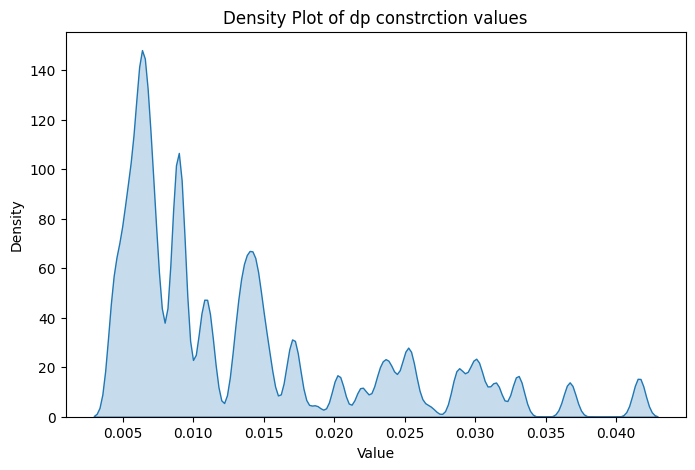

In [ ]:
import seaborn as sns
np.random.seed(42)
dp =  np.concatenate([dataTest[:, i, 4] for i in np.arange(0, 40)]) # market d/p


# Creating density plot
plt.figure(figsize=(8, 5))
sns.kdeplot(dp, fill=True)
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Density Plot of dp constrction values')
plt.show()

In [ ]:
first_period_data = dataTest[:, 0, :]

# Compute mean across all 200 samples (resulting in shape: (1,6))
mean_first_period = np.mean(first_period_data, axis=0, keepdims=True)
mean_all_array = np.mean(dataTest, axis=(0,1), keepdims=True)
print(mean_first_period)
print(mean_all_array)

[[1.09599802 1.08094314 1.0076877  0.02757285 0.01360896 1.
  1.01998794]]
[[[1.09642128 1.08247714 1.00753101 0.02747589 0.01351145 0.51219512
   1.02006144]]]


In [ ]:
#total of the margin effect
#construction dp ratio impact
# Define parameters
num_points = 50  # Number of sample points
x_values = np.linspace(0.00,0.04 , num_points)  # Generate values for the 5th variable
period_indices = [0,20,40]

colors = ["b", "r", "g"]  # Colors for each line
labels = ["Period 0", "Period 20", "Period 40"]  # Labels for legend

plt.figure(figsize=(8, 5))  # Create figure for plotting

# Loop over different first_period_data selections
for idx, period in enumerate(period_indices):
    # Extract first period data for the given period index
    first_period_data = dataTest[:, period, :]

    # Expand first_period_data along a new axis to accommodate all x_values
    modified_data = np.repeat(first_period_data[:, np.newaxis, :], num_points, axis=1)

    # Update the 5th variable (column index 3) for all data points
    modified_data[:, :, 4] = x_values  # Broadcasting assigns x_values across all samples

    # Apply the function in a loop for vectorized calculations
    weightsOut = np.array([
        np.array([modelPol.policyFunctionConsIncEval_snap(par, modified_data[j, i, :].reshape(1, -1))
                  for j in range(modified_data.shape[0])])
        for i in range(modified_data.shape[1])
    ])

    # Compute mean over all samples to get construction portfolio
    y_values = np.mean(weightsOut[:, :, 0], axis=1)  # Extract 2nd variable in weightsOut2

    # Convert y_values to a NumPy array (if not already)
    y_values = np.asarray(y_values)

    # Plot the result for the current `first_period_data`
    plt.plot(x_values, y_values, marker="o", linestyle="-", color=colors[idx], label=labels[idx])

# Configure plot labels and title
plt.xlabel("Maunf D/P")
plt.ylabel("Maunf Portfolio")
plt.title("Effect of Changing Maunf D/P on Constr Portfolio for Different Periods")
plt.legend()  # Add legend for different lines
plt.grid()
plt.show()  # Display the plot

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-17-a74352d42b2a>", line 25, in <cell line: 0>
    weightsOut = np.array([
                          ^
  File "<ipython-input-17-a74352d42b2a>", line 26, in <listcomp>
    np.array([modelPol.policyFunctionConsIncEval_snap(par, modified_data[j, i, :].reshape(1, -1))
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<ipython-input-17-a74352d42b2a>", line 26, in <listcomp>
    np.array([modelPol.policyFunctionConsIncEval_snap(par, modified_data[j, i, :].reshape(1, -1))
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<ipython-input-7-51f4e42d2ce4>", line 188, in policyFunctionConsIncEval_snap
    weightsOut= tmpPortfolio / np.sum(tmpPortfolio)
                     

TypeError: object of type 'NoneType' has no len()

<Figure size 800x500 with 0 Axes>

In [ ]:
#total of the margin effect
#market dp ratio impact
# Define parameters
num_points = 50  # Number of sample points
x_values = np.linspace(0, 0.05, num_points)  # Generate values for the 5th variable

# Define the indices for first_period_data selections
colors = ["b", "r", "g"]  # Colors for each line
labels = ["Period 0", "Period 20", "Period 40"]  # Labels for legend

period_indices =[0,20,40]
plt.figure(figsize=(8, 5))  # Create figure for plotting

# Loop over different first_period_data selections
for idx, period in enumerate(period_indices):
    # Extract first period data for the given period index
    first_period_data = dataTest[:, period, :]

    # Expand first_period_data along a new axis to accommodate all x_values
    modified_data = np.repeat(first_period_data[:, np.newaxis, :], num_points, axis=1)

    # Update the 5th variable (column index 3) for all data points
    modified_data[:, :, 3] = x_values  # Broadcasting assigns x_values across all samples

    # Apply the function in a loop for vectorized calculations
    weightsOut = np.array([
        np.array([modelPol.policyFunctionConsIncEval_snap(par, modified_data[j, i, :].reshape(1, -1))
                  for j in range(modified_data.shape[0])])
        for i in range(modified_data.shape[1])
    ])

    # Compute mean over all samples to get construction portfolio
    y_values = np.mean(weightsOut[:, :, 1], axis=1)  # Extract 2nd variable in weightsOut2

    # Convert y_values to a NumPy array (if not already)
    y_values = np.asarray(y_values)

    # Plot the result for the current `first_period_data`
    plt.plot(x_values, y_values, marker="o", linestyle="-", color=colors[idx], label=labels[idx])

# Configure plot labels and title
plt.xlabel("Market D/P")
plt.ylabel("Market Portfolio")
plt.title("Effect of Changing Market D/P on Market Portfolio for Different Periods")
plt.legend()  # Add legend for different lines
plt.grid()
plt.show()  # Display the plot

KeyboardInterrupt: 

<Figure size 800x500 with 0 Axes>

0 1
1 0.5
2 0.02


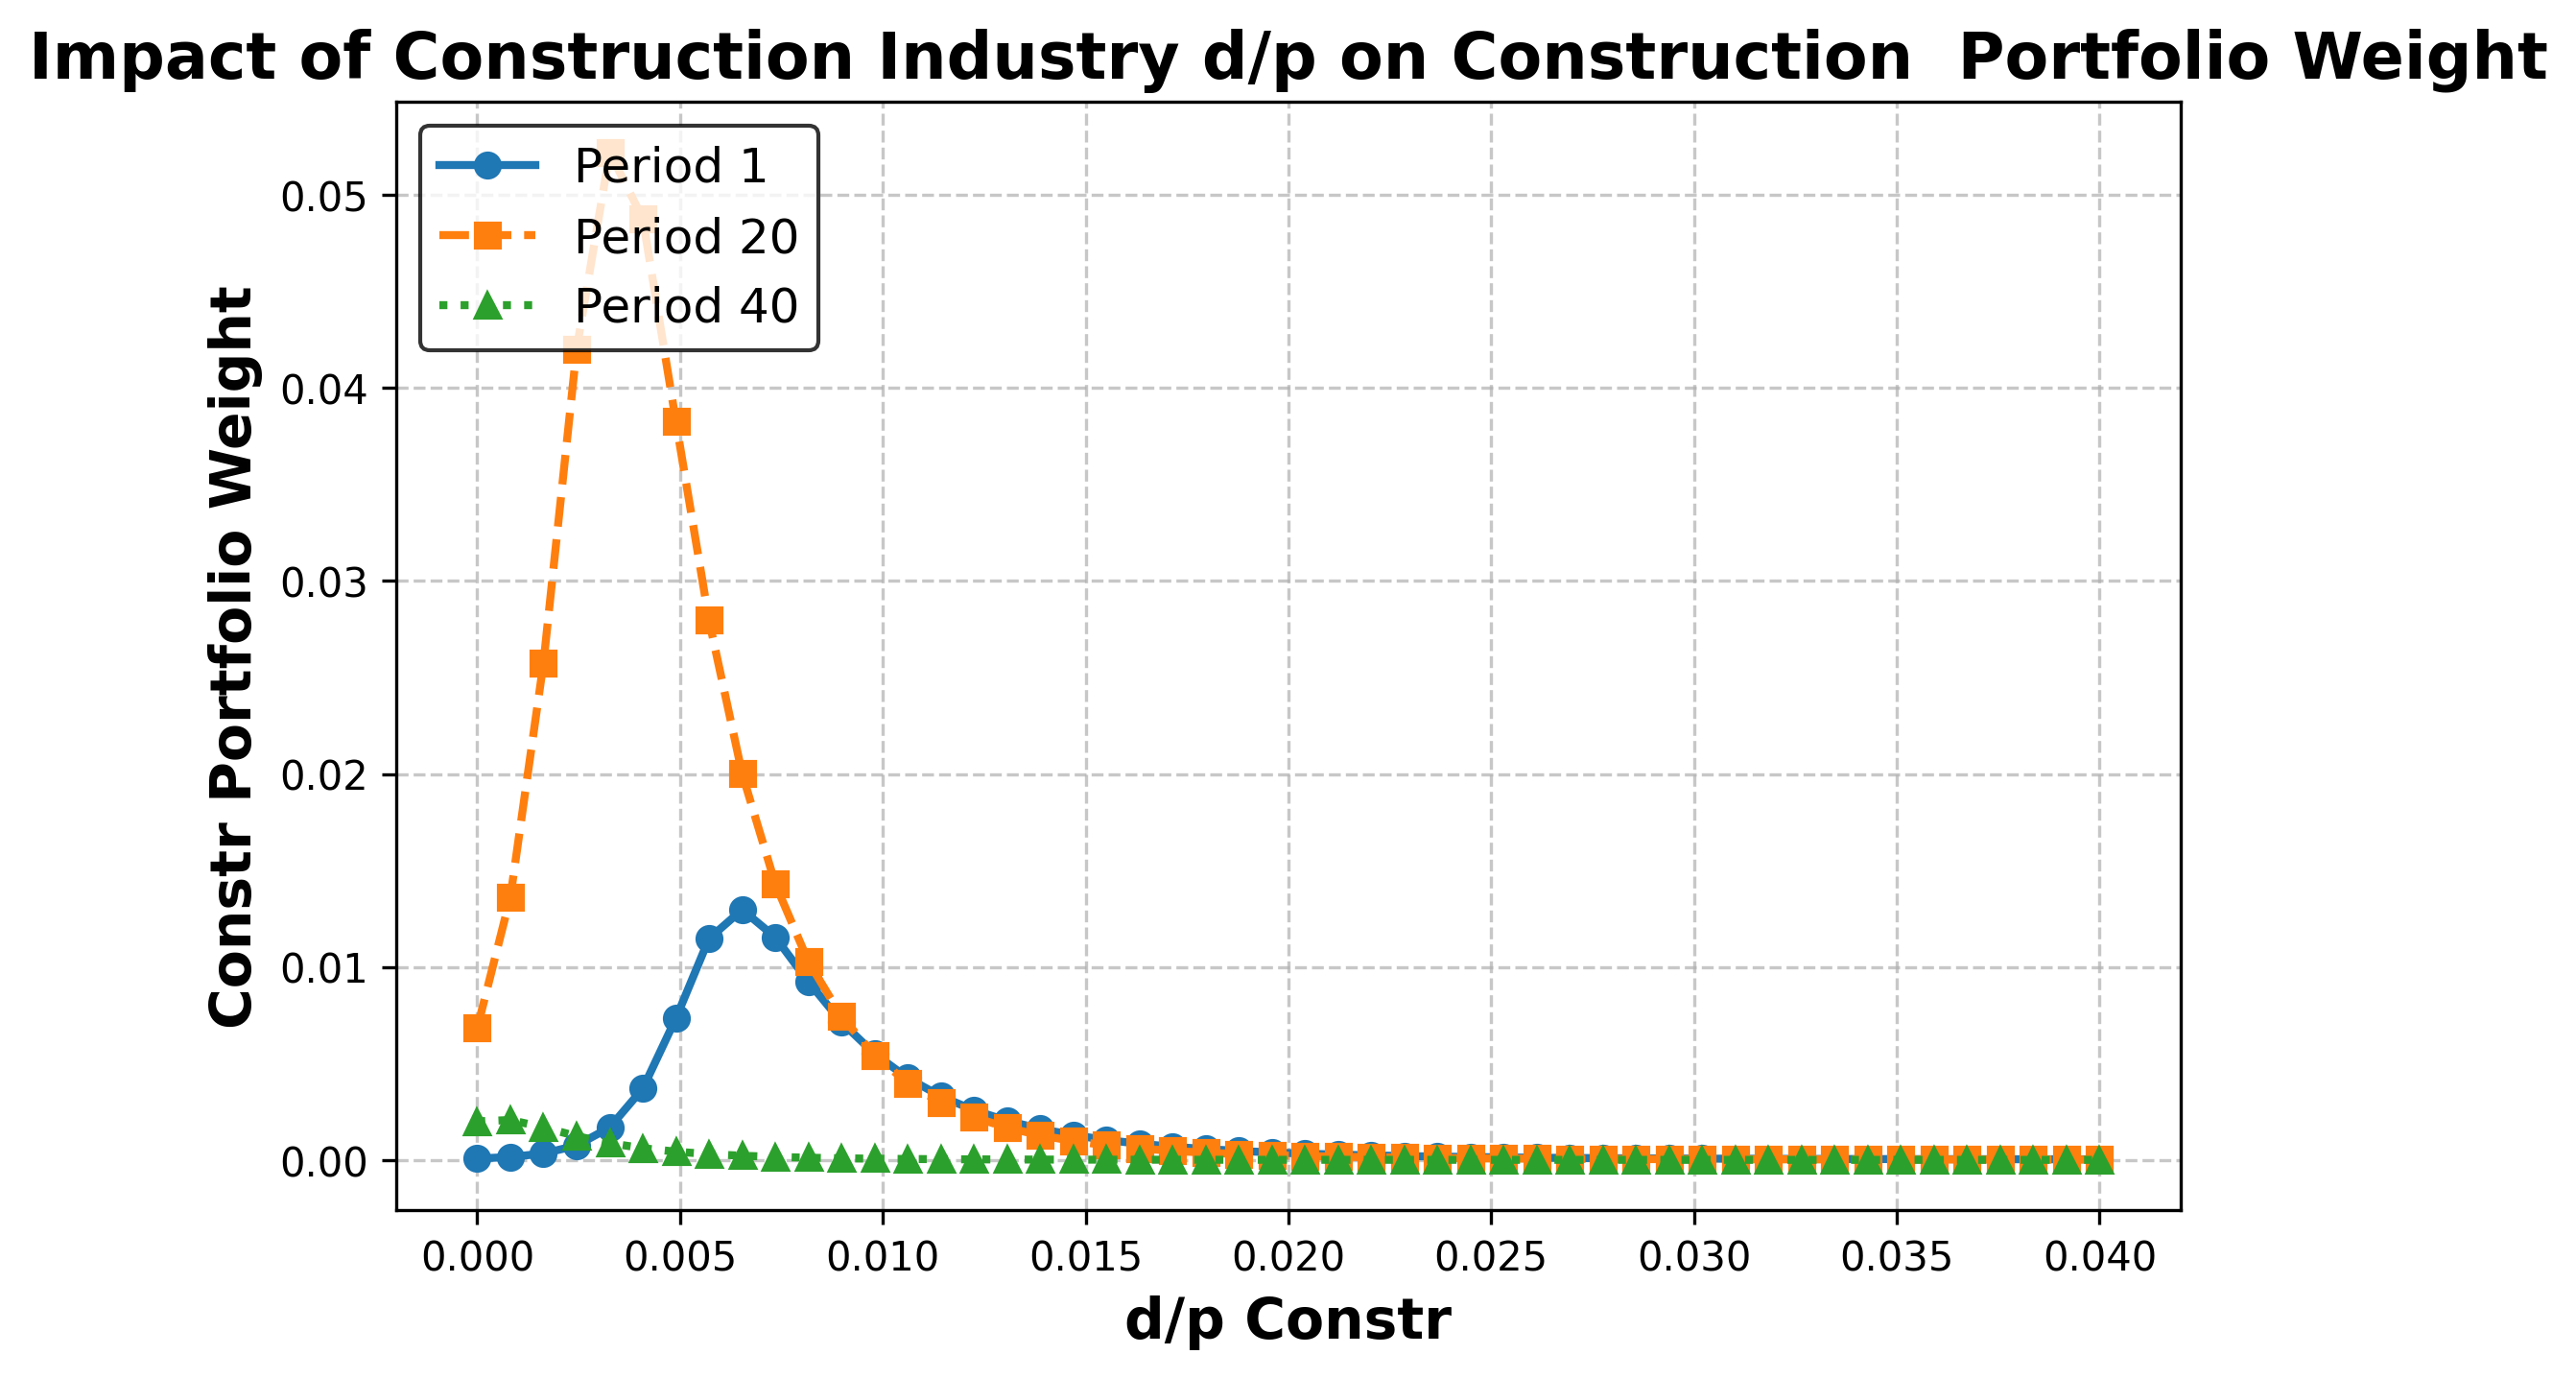

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

first_period_data = dataTest[:, 0, :]
# Step 1: Extract the original mean_first_period (shape: (1,7))
original_mfp = mean_first_period.copy()  # Shape: (1,7)

# Step 2: Define the different values for the 6th element (index 5)
time = [1, 0.5, 0.02]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Using more elegant academic colors
markers = ['o', 's', '^']  # Different markers for clarity
linestyles = ['-', '--', ':']  # Line styles for differentiation
labels = ['Period 1', 'Period 20', 'Period 40']

# Step 3: Generate values for the 5th element (index 4)
num_points = 50  # Number of points to evaluate
x_values = np.linspace(0.0,0.04, num_points)

# Step 4: Create figure with high DPI
plt.figure(figsize=(8,5), dpi=300)  # High resolution for publication

# Step 5: Loop over different values of the 6th element
for i, sixth_value in enumerate(time):
    y_values = []  # Store y-values for this iteration
    print(i, sixth_value)

    for x in x_values:
        modified_mfp = original_mfp.copy()  # Keep other elements unchanged
        modified_mfp[0, 4] = x  # Modify only the 5th element
        modified_mfp[0, 5] = sixth_value  # Set the 6th element to current value

        # Call the model function
        weightsOut = modelPol.policyFunctionConsIncEval_snap(par, modified_mfp)

        # Directly access the 2nd element from weightsOut (since it's 1D)
        y_values.append(weightsOut[0])

    # Plot the results for this setting
    plt.plot(x_values, y_values, marker=markers[i], linestyle=linestyles[i],
             color=colors[i], label=labels[i], markersize=6, linewidth=2)

# Step 6: Format the plot for an academic paper
plt.xlabel("d/p Constr", fontsize=14, fontweight='bold')
plt.ylabel("Constr Portfolio Weight", fontsize=14, fontweight='bold')
plt.title("Impact of Construction Industry d/p on Construction  Portfolio Weight", fontsize=16, fontweight='bold')
plt.legend(fontsize=12, loc='upper left', frameon=True, edgecolor='black')  # Better legend positioning
plt.grid(True, linestyle='--', alpha=0.7)  # Dotted grid lines for readability

# Save figure as high-quality PDF
plt.savefig("academic_plot.pdf", format="pdf", bbox_inches="tight")

# Show the plot
plt.show()


In [ ]:
consOut_list = []
weightsOut_all_periods = []
wealthOut_all_periods = np.empty((0, 1))
consWealthOut_all_periods = np.empty((0, 1))

iConsume = 1
numPeriods = 40
base = np.array(utilPars[-1])  # Ensure it's a NumPy array (or just use float)

# Create the exponent range (from 0 to numPeriods)
exponents = np.arange(0, numPeriods + 1, dtype=np.float32)  # Ensure float type
# Compute the power
adjustFactor = np.power(base, exponents)  # Equivalent to tf.pow()

for idata in dataTest:

    (weightsOut, wealthOut, consOut, consWealthOut) = modelPol.policyFunctionConsIncEval(par, idata)
    #weightsOut_all_periods.append(weightsOut)
    consWealthOut_all_periods = np.append(consWealthOut_all_periods, consWealthOut, axis=0)
    wealthOut_all_periods = np.append(wealthOut_all_periods,wealthOut,axis=0)

    consOut_squeezed = consOut.squeeze()
    consOut_extended = np.append(consOut_squeezed, wealthOut[-1])
    consOut_list.append(consOut_extended)



In [ ]:
consOut_array = np.array(consOut_list)
utility_values = investorPol.utility(consOut_array+0.001, utilPars)  # Assuming y_pred is already a NumPy array


# Compute the mean along axis 0
mean_utility = -np.mean(utility_values, axis=0)
# Compute the batch loss
batch_loss = - np.sum(adjustFactor * mean_utility)

weightsOut_mean = np.mean(weightsOut_all_periods, axis=0)
consWealthOut_all_periods = np.reshape(consWealthOut_all_periods, (-1, 40))
consWealthOutAll_mean = np.mean(consWealthOut_all_periods, axis=0)

print(batch_loss*10000)

-40.52137712389179


In [ ]:
from multiprocessing import Manager, Process

In [ ]:
if __name__ == "__main__":

  #delta = np.array([0.01,1e-4,1e-6])
  #risk_coefficient = np.array([2, 4, 6])
  delta = np.array([1e-4])
  risk_coefficient = np.array([4])

  for idx, r in enumerate(risk_coefficient) :

    parsOptPol["parUtil"][0] = r
    parsOptPol["min_delta"] = delta[idx]


    for i in range(0,1):

      print("Training the model: {}".format(industry_names[i]))
      #weight_temp = np.empty((numPeriods, 0))
      #consWealth_temp = np.empty((numPeriods, 0))
      indus_index = i + 14
      #parsOptPol["simDataPolicy"] = np.concatenate((simEconomyPol[:,0:2],simEconomyPol[:,-2:]),axis=1)


      parsOptPol["simDataPolicy"] = np.concatenate((simEconomyPol[:,[i]],simEconomyPol[:,8:11],simEconomyPol[:,[11]],simEconomyPol[:,[-1]],simEconomyPol[:,[indus_index]]),axis=1)
      numPeriodsSimTest_index = parsPol["numBatchesTest"] * numSimPol * (numPeriods + 1)
      dataTest = simEconomyPol[-numPeriodsSimTest_index:, :]
      dataTest = np.concatenate((dataTest[:,[i]],dataTest[:,8:11],dataTest[:,[11]],dataTest[:,[-1]],dataTest[:,[indus_index]]),axis=1)
      dataTest = np.reshape(dataTest,(-1,41,numAssets+numStates+2))

      parsOptPol["industry"] = industry_names[i]
      modelPol = portfolioDiscreteNew(investorPol, economyPol, parsOptPol)


      with Manager() as manager:
        results = manager.dict()

        # Create processes
        processes = []
        for j in range(0,3):
            p = Process(target=modelPol.optPortfConsIncNeuralNetPolicy,args=(j,results))
            processes.append(p)
            p.start()

        # Wait for all processes to finish
        for p in processes:
            p.join()

      #best_process = np.min(results.items(), key=lambda x: x[1]['min_val_loss'])
      #best_process_id, best_process_result = best_process
      #print(f"Best process: {best_process_id} with min validation loss = {best_process_result['min_val_loss']}")

      # Retrieve the weights of the best model
      #best_model_weights = best_process_result['weights']
      #print(f"Retrieved weights of the best model from process {best_process_id}")



Training the model: Construction
Running code for the solution using a policy function determined by a neural network: Consumption and portfolio decision with income
The setup is:
Model: bootstrap_data_Ic_9Running code for the solution using a policy function determined by a neural network: Consumption and portfolio decision with income

Utility: PowerThe setup is:
Process 0 (PID 42039) started.

Model: bootstrap_data_Ic_9
Utility: Power
Process 1 (PID 42043) started.Running code for the solution using a policy function determined by a neural network: Consumption and portfolio decision with income

The setup is:
Model: bootstrap_data_Ic_9
Utility: Power
Process 2 (PID 42055) started.


KeyboardInterrupt: 

In [ ]:
def intertemporal_crra_utility_NN(dataTest, portfolio_weights, initial_income, initial_wealth, consumption_wealth_ratio, gamma, delta):

    num_periods = dataTest.shape[0]
    current_wealth = initial_wealth
    current_income = initial_income
    total_utility = 0
    adjustFactor = np.power(delta, np.array(range(0,num_periods)))

    for period in range(0,20):

        current_wealth = current_wealth + current_income

        # Compute portfolio returns
        portfolio_return = np.dot(portfolio_weights[period,:], dataTest[period+1,:26])

        # Total resources for the period (portfolio return + income)
        total_resources = current_wealth * portfolio_return

        # Compute consumption
        consumption = consumption_wealth_ratio[period] * total_resources

        # Update wealth after consumption
        current_wealth = total_resources - consumption

        utility =  adjustFactor[period] * (consumption ** (1 - gamma)) / (1 - gamma)

        total_utility +=  utility

        current_income  =  current_income  * dataTest[period, -1]


    bequest_utility = np.power(delta,20) * (current_wealth ** (1 - gamma)) / (1 - gamma)

    total_utility += bequest_utility

    return total_utility

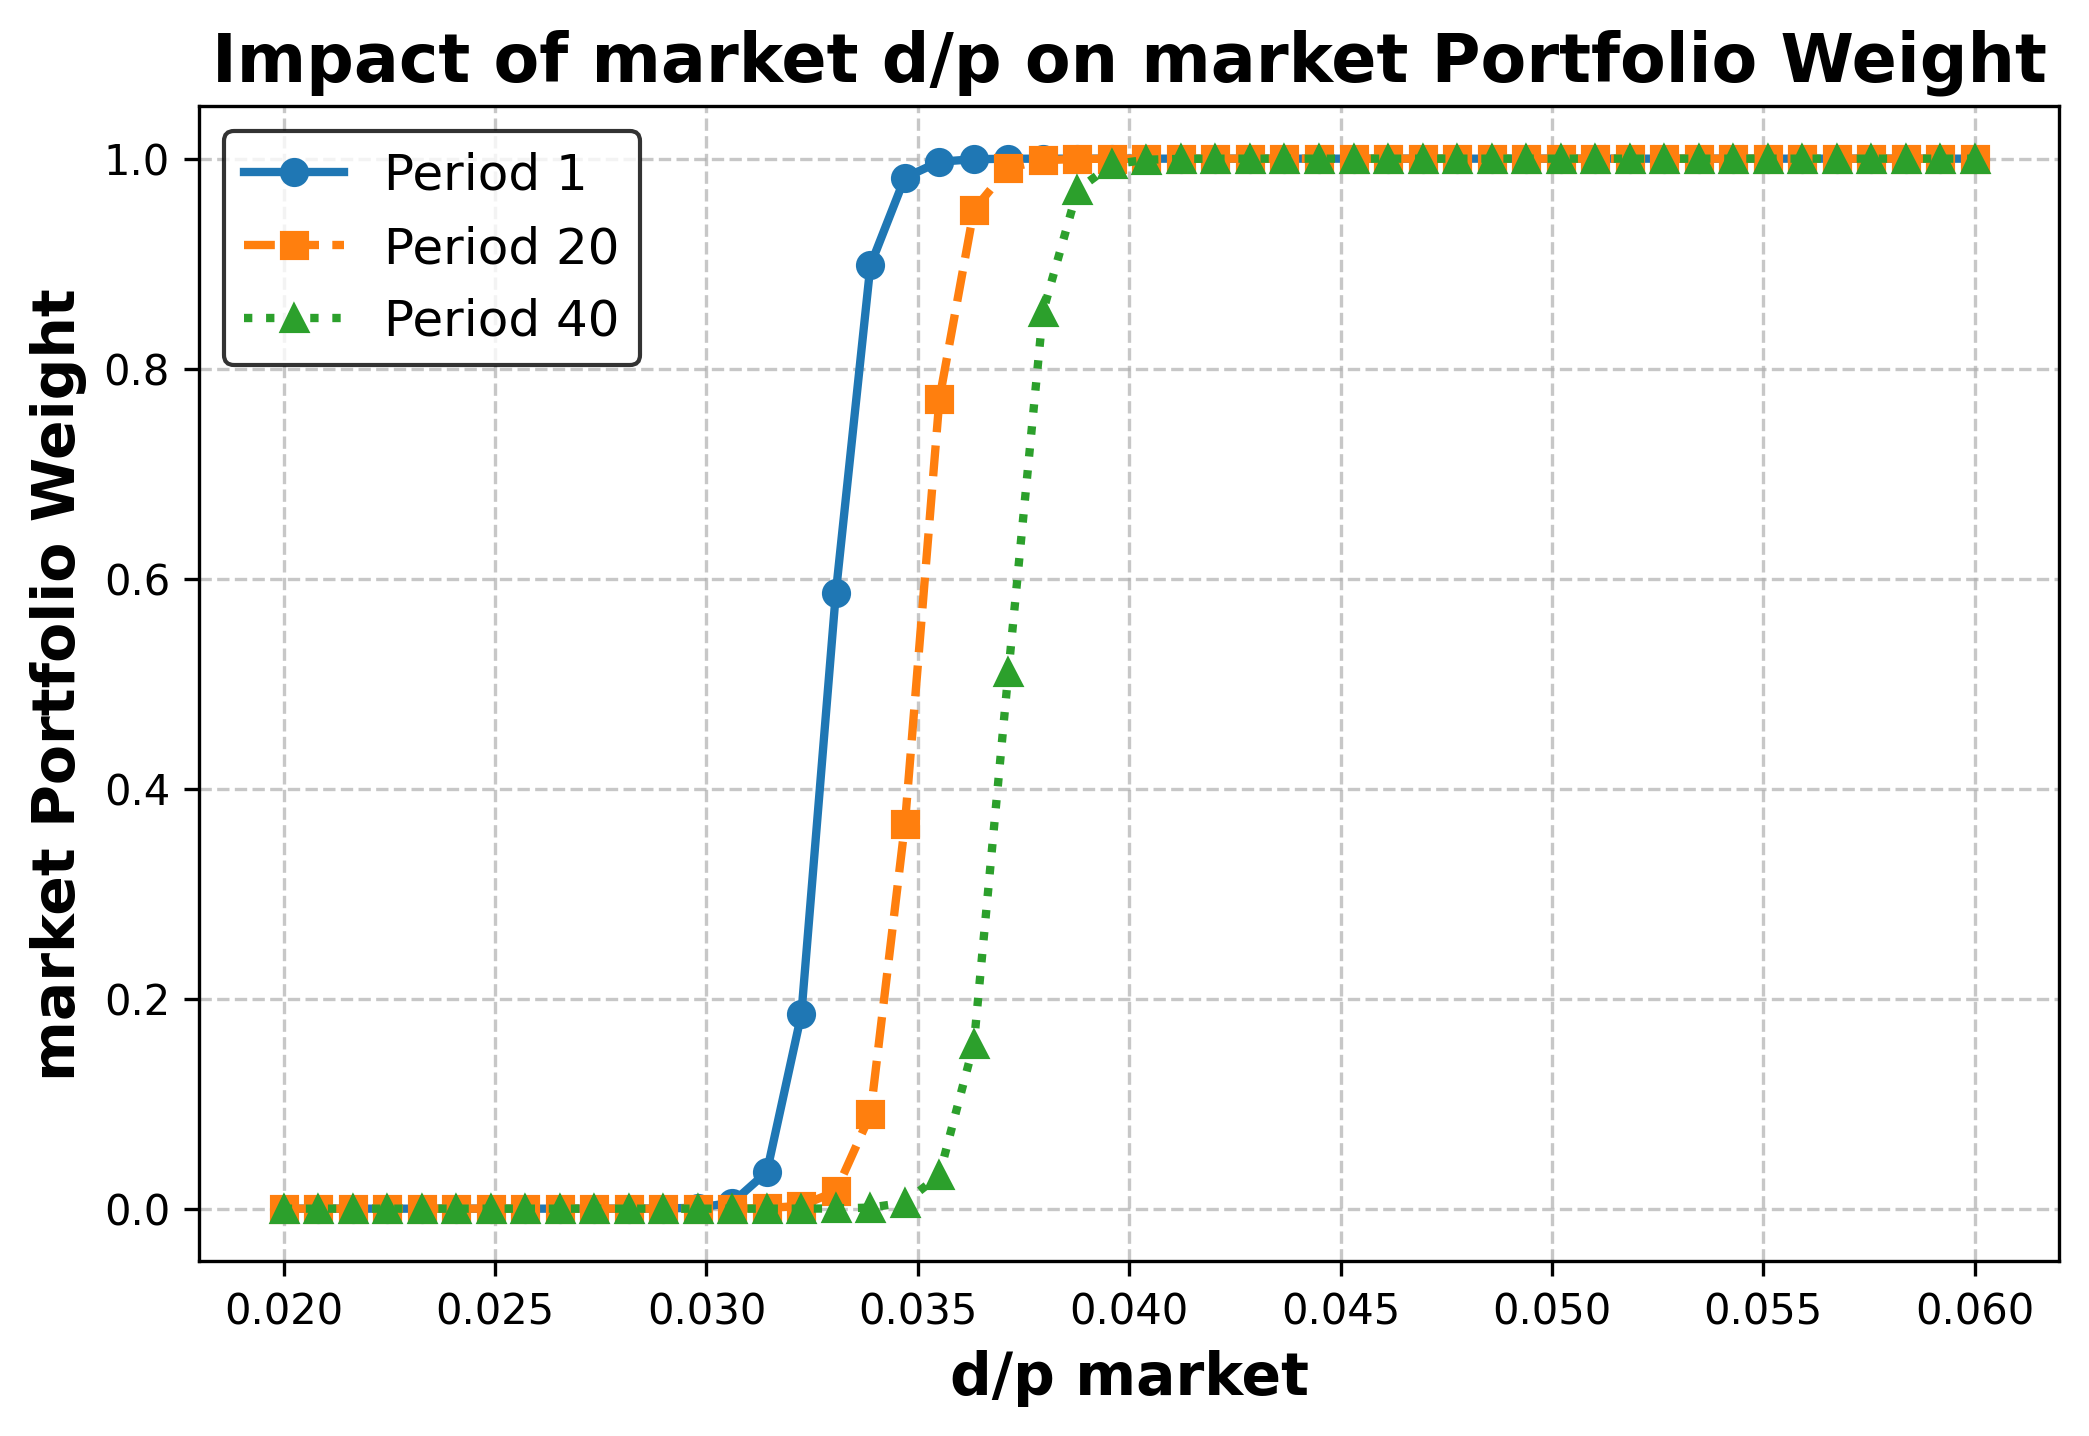

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Extract the original mean_first_period (shape: (1,7))
original_mfp = mean_first_period.copy()  # Shape: (1,7)

# Step 2: Define the different values for the 6th element (index 5)
time = [1,0.5,0.02]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Using more elegant academic colors
markers = ['o', 's', '^']  # Different markers for clarity
linestyles = ['-', '--', ':']  # Line styles for differentiation
labels = ['Period 1', 'Period 20', 'Period 40']

# Step 3: Generate values for the 5th element (index 4)
num_points = 50  # Number of points to evaluate
x_values = np.linspace(0.02, 0.06, num_points)

# Step 4: Create figure with high DPI
plt.figure(figsize=(8,5), dpi=300)  # High resolution for publication

# Step 5: Loop over different values of the 6th element
for i, sixth_value in enumerate(time):
    y_values = []  # Store y-values for this iteration

    for x in x_values:
        modified_mfp = original_mfp.copy()  # Keep other elements unchanged
        modified_mfp[0, 3] = x  # Modify only the 5th element
        modified_mfp[0, 5] = sixth_value  # Set the 6th element to current value

        # Call the model function
        weightsOut = modelPol.policyFunctionConsIncEval_snap(par, modified_mfp)

        # Directly access the 2nd element from weightsOut (since it's 1D)
        y_values.append(weightsOut[1])

    # Plot the results for this setting
    plt.plot(x_values, y_values, marker=markers[i], linestyle=linestyles[i],
             color=colors[i], label=labels[i], markersize=6, linewidth=2)

# Step 6: Format the plot for an academic paper
plt.xlabel("d/p market", fontsize=14, fontweight='bold')
plt.ylabel("market Portfolio Weight", fontsize=14, fontweight='bold')
plt.title("Impact of market d/p on market Portfolio Weight", fontsize=16, fontweight='bold')
plt.legend(fontsize=12, loc='upper left', frameon=True, edgecolor='black')  # Better legend positioning
plt.grid(True, linestyle='--', alpha=0.7)  # Dotted grid lines for readability

# Save figure as high-quality PDF
plt.savefig("academic_plot.pdf", format="pdf", bbox_inches="tight")

# Show the plot
plt.show()


In [ ]:
def process_data(idata, modelParPol,modelPol):
    # Compute policy function outputs

    weightsOut, wealthOut, consOut, consWealthOut = modelPol.policyFunctionConsIncEval(modelParPol, idata)

    # Compute utility
    indir_uil = intertemporal_crra_utility_NN(idata, weightsOut, 1, 1, consWealthOut, 4, 0.96)

    # Return relevant results
    return indir_uil


In [ ]:
#########################################################
#result testing set

weight_temp = []
consWealth_temp = []

#min_index = np.array([1,2,0,3])
#risk_aversion = np.array([4,6,8,10])
risk_aversion = 4
min_index = 2

for i in np.arange(0,1):

    print("Testing the model: {}".format(industry_names[0]))
    #print("The risk aversion is : {}".format(risk_aversion[i]))
    parsOptPol["simDataPolicy"] = np.concatenate((simEconomyPol[:,0:numAssets],simEconomyPol[:,-2:],simEconomyPol[:,[numAssets+i]]),axis=1)
    parsOptPol["industry"] = industry_names[0]
    numPeriodsSimTest_index = parsPol["numBatchesTest"] * numSimPol * (numPeriods + 1)
    dataTest = simEconomyPol[-numPeriodsSimTest_index:, :]
    dataTest = np.concatenate((dataTest[:,0:numAssets],dataTest[:,-2:],dataTest[:,[numAssets+i]]),axis=1)
    dataTest = np.reshape(dataTest,(-1,21,29))
    parsOptPol["parUtil"][0] = 4

    #pathExcel = os.path.join(my_path, 'resultsExperiment', 'bootstrapResult_gamma4_FF25',modelUsed + industry_names[i] + '010.xlsx')
    #data = pd.read_excel(pathExcel)
    #min_index = data["val_loss"].idxmin()

    modelPol = portfolioDiscreteNew(investorPol, economyPol, parsOptPol)
    ParFilePol = modelPol.get_weights_filepath(2)

    with open(ParFilePol, 'rb') as file:
        modelParPol = pickle.load(file)

    # Parallel computation
    results = Parallel(n_jobs=-1)(delayed(process_data)(idata,modelParPol,modelPol) for idata in dataTest)

    # Compute the mean utility
    uil_mean = np.mean(results, axis=0)

    # Print or return the results
    print("Mean Utility:", uil_mean)


'''
    weightsOut_all_periods = []
    consWealthOut_all_periods = np.empty((0, 1))
    uil_collec = []
    uil_mean = []

    for idata in dataTest:

       (weightsOut, wealthOut, consOut, consWealthOut) = modelPol.policyFunctionConsIncEval(modelParPol, idata)
       #weightsOut_all_periods.append(weightsOut)
       #consWealthOut_all_periods = np.append(consWealthOut_all_periods, consWealthOut, axis=0)
       indir_uil = intertemporal_crra_utility_NN(idata, weightsOut,1,1,consWealthOut, risk_aversion, 0.96, adjustFactor)
       uil_collec.append(indir_uil)

    uil_mean= np.mean(uil_collec, axis=0)


    #weightsOut_mean = np.mean(weightsOut_all_periods, axis=0)
    #weightsOut_mean[weightsOut_mean<1e-3] = 0

    #weightsOut_all_periods = np.array(weightsOut_all_periods)
    #in_samples = weightsOut_all_periods.shape[0]

    # Calculate the standard error of the mean (SEM) along axis=0
    #sem = np.std(weightsOut_all_periods, axis=0, ddof=1) / np.sqrt(n_samples)

    # Get the z-score for a 90% confidence interval
    z_score = norm.ppf(0.95)  # 90% CI -> 5% in upper tail

    # Calculate the confidence interval bounds
    ci_lower = weightsOut_mean - z_score * sem
    ci_upper = weightsOut_mean + z_score * sem
    ci_lower[ci_lower<1e-3] = 0
    ci_upper[ci_upper<1e-3] = 0

    print("Model: {}".format(industry_names[i]))
    print("portfolio weight over the time")
    print(weightsOut_mean)
    #print(weightsOut_mean.shape)
    #print(ci_lower)
    #print(ci_upper)

    #weightsOut_all_periods = np.array(weightsOut_all_periods)
    consWealthOut_all_periods = np.reshape(consWealthOut_all_periods, (-1, 20))

    consWealthOutAll_mean = np.mean(consWealthOut_all_periods, axis=0)
    std_consWealthOutAll = np.std(consWealthOut_all_periods, axis=0, ddof=1)
    margin_of_error = norm.ppf(0.90) * (std_consWealthOutAll / np.sqrt(std_consWealthOutAll.shape[0]))
    consWealthOutAll_10 = consWealthOutAll_mean - margin_of_error
    consWealthOutAll_90 = consWealthOutAll_mean + margin_of_error

    print("Model: {}".format(industry_names[i]))
    print("consumption over the tim")
    print (consWealthOutAll_10, consWealthOutAll_mean,consWealthOutAll_90)

    weight_temp.append(weightsOut_mean)
    consWealth_temp.append((consWealthOutAll_10, consWealthOutAll_mean,consWealthOutAll_90))
'''

In [ ]:
# Plot the data
import matplotlib.pyplot as plt
# Data for consumption/wealth ratio over time
time = np.arange(1, 21)  # 20 time periods
consWealthOutAll_10=  consWealth_temp[2][0]
consWealthOutAll_mean= consWealth_temp[2][1]

consWealthOutAll_90 = consWealth_temp[2][2]
plt.figure(figsize=(10, 6))
plt.plot(time,consWealthOutAll_mean, label='Mean', color='blue', linewidth=2)
plt.fill_between(time, consWealthOutAll_10,consWealthOutAll_90, color='blue', alpha=0.2, label='95% Confidence Interval')
plt.xlabel('Time Period')
plt.ylabel('Consumption/Wealth Ratio')
plt.title('Consumption/Wealth Ratio Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
def calculate_certainty_equivalent(indirect_utility, gamma, periods, discount_factor):

    # Compute the discount factor sum
    discount_factor_sum = sum(discount_factor ** t for t in range(periods))

    # Calculate CE for CRRA utility (gamma != 1)
    if gamma != 1:
        ce = ((1 - gamma) * indirect_utility / discount_factor_sum) ** (1 / (1 - gamma))
    else:
        # Calculate CE for logarithmic utility (gamma == 1)
        ce = (indirect_utility / discount_factor_sum) ** (1 / periods)

    return ce


# Example Inputs
indirect_utility =  -0.00571  # Aggregated utility (example value)
gamma = 10            # Risk aversion coefficient
periods = 21                  # Number of periods
discount_factor = 0.96       # Discount factor (beta)

# Calculate Certainty Equivalent
certainty_equivalent = calculate_certainty_equivalent(
    indirect_utility, gamma, periods, discount_factor
)

print(f"Certainty Equivalent (CE): {certainty_equivalent:.2f}")

In [ ]:
import statsmodels.api as sm
dp_con = np.concatenate([dataTest[:, i, 4] for i in np.arange(0, 40)])
dp_mkt = np.concatenate([dataTest[:, i, 3] for i in np.arange(0, 40)])
r_mkt_lag = np.concatenate([dataTest[:, i, 1] for i in np.arange(0, 40)])
constr_p_lag = np.concatenate([dataTest[:, i, 0] for i in np.arange(0, 40)])
r_mkt = np.concatenate([dataTest[:, i, 1] for i in np.arange(1, 41)])
r_mkt = np.concatenate([dataTest[:, i, 1] for i in np.arange(1, 41)])
constr_p = np.concatenate([dataTest[:, i, 0] for i in np.arange(1, 41)])

#r_mkt = np.roll(r_mkt, -1)  # Moves all values up by 1
#r_mkt = r_mkt[:-1]  # Remove the last value (which wraps around)

#constr_p = np.roll(constr_p, -1)  # Moves all values up by 1
#constr_p = constr_p[:-1]  # Remove the last value (which wraps around)

#dp_con = dp_con[:-1]  # Independent variable Y_t (remove last value to match dimensions)
#dp_mkt = dp_mkt[:-1]  # Independent variable Z_t (remove last value to match dimensions)

# Stack independent variables into a matrix
independent_vars = np.column_stack((r_mkt_lag,constr_p_lag, dp_mkt, dp_con))

# Add constant for intercept
independent_vars = sm.add_constant(independent_vars)

# Fit the regression model
model_1 = sm.OLS(constr_p, independent_vars).fit()

model_2 = sm.OLS(r_mkt, independent_vars).fit()
# Print regression summary
print(model_1.summary())
print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                 1.392e+04
Date:                Thu, 27 Feb 2025   Prob (F-statistic):               0.00
Time:                        12:09:23   Log-Likelihood:            -2.4624e+05
No. Observations:             2000000   AIC:                         4.925e+05
Df Residuals:                 1999995   BIC:                         4.926e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3521      0.001    981.983      0.0